[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter4_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 4: Portfolio Optimization

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces the main charts and numbers of Lecture 4 (Sections 1–8; the case study and the AI mini-case have their own Quantlets):
- US sector ETFs, multi-asset ETFs (equities, Treasuries, credit, gold), BVB blue chips, BET and BET-TR (daily prices provided with the course);
- the one-month risk-free rate (Kenneth French Data Library).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_4'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import io
import re
import json
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from scipy.cluster.hierarchy import linkage, leaves_list, dendrogram
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

## Data

- ETFs and stocks: adjusted prices; indices (BET, BET-TR): closing values.
- Multi-asset analyses align the **prices** on common trading days, then take month-end returns.
- BVB: days with a daily log return above 0.5 in absolute value are treated as data errors.

In [2]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
FRENCH = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
BNR_XML = 'https://curs.bnr.ro/files/xml/years/nbrfxrates{}.xml'

SECTORS = ['XLB', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLU', 'XLV', 'XLY']        # from Dec 1998
SECTOR_NAMES = {'XLB': 'Materials', 'XLE': 'Energy', 'XLF': 'Financials', 'XLI': 'Industrials',
                'XLK': 'Technology', 'XLP': 'Cons. staples', 'XLU': 'Utilities', 'XLV': 'Health care',
                'XLY': 'Cons. discretionary'}
MULTI = ['SPY', 'EFA', 'EEM', 'TLT', 'IEF', 'LQD', 'HYG', 'GLD']                  # HYG from Apr 2007
MULTI_NAMES = {'SPY': 'US equities', 'EFA': 'Developed ex-US', 'EEM': 'Emerging markets',
               'TLT': 'US Treasuries 20y+', 'IEF': 'US Treasuries 7-10y', 'LQD': 'Investment-grade credit',
               'HYG': 'High-yield credit', 'GLD': 'Gold'}
BVB = ['TLV', 'SNP', 'BRD', 'TGN', 'SNG', 'SNN', 'EL', 'TEL']                      # listed before 2014-09
BVB_NAMES = {'TLV': 'Banca Transilvania', 'SNP': 'OMV Petrom', 'BRD': 'BRD-GSG', 'TGN': 'Transgaz',
             'SNG': 'Romgaz', 'SNN': 'Nuclearelectrica', 'EL': 'Electrica', 'TEL': 'Transelectrica'}

_CACHE = {}


def read_market(symbol):
    """Daily price table of one symbol (course data)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def price(symbol):
    """Price used: adjusted close for ETFs and stocks, close for indices and crypto."""
    d = read_market(symbol)
    col = 'close' if symbol.endswith('.INDX') or symbol.endswith('.CC') or symbol == 'BET' else 'adjusted_close'
    s = d[col].astype(float)
    return s[s > 0].rename(symbol)


def prices(symbols, start=None, end=None):
    """Prices aligned on common days (multi-asset analyses align prices first, then take returns)."""
    p = pd.concat([price(s) for s in symbols], axis=1).dropna()
    return p.loc[start:end]


def log_returns(p):
    """Log returns of a table already aligned on common days."""
    return np.log(p).diff().dropna()


def french_rf():
    """Monthly risk-free rate (one-month T-bill) from the Fama-French three-factor file, in decimals."""
    if 'rf' in _CACHE:
        return _CACHE['rf']
    url = FRENCH + 'F-F_Research_Data_Factors_CSV.zip'
    raw = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'}),
                                 timeout=120).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    text = z.read(z.namelist()[0]).decode('latin-1')
    rows = []
    for line in text.splitlines():
        parts = [x.strip() for x in line.split(',')]
        if len(parts) == 5 and len(parts[0]) == 6 and parts[0].isdigit():
            rows.append((parts[0], float(parts[4]) / 100.0))
        elif rows and not (len(parts[0]) == 6 and parts[0].isdigit()):
            break
    rf = pd.Series(dict(rows))
    rf.index = pd.to_datetime(rf.index, format='%Y%m') + pd.offsets.MonthEnd(0)
    _CACHE['rf'] = rf.rename('RF')
    return _CACHE['rf']


def monthly_returns(symbols, start=None):
    """Monthly simple returns from month-end prices (common days)."""
    p = prices(symbols).resample('ME').last()
    return p.pct_change().dropna().loc[start:]


def bnr_rate(currency='USD', start=2014, end=2026):
    """BNR reference rate: RON per unit of currency (annual XML archives)."""
    key = ('bnr', currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(start, end + 1):
        xml = urllib.request.urlopen(urllib.request.Request(BNR_XML.format(y), headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"( multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(2))))
    s = pd.Series(dict(rows)).sort_index()
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.rename(f'{currency}RON')
    return _CACHE[key]

## Style, estimators and backtest engine

- Weights: 1/N, MV (tangency), MV-LO, GMV, GMV-LO, GMV-LW (Ledoit–Wolf, constant correlation), ERC, HRP.
- Backtest: 60-month rolling window, monthly rebalancing, turnover from drifted weights.
- Inference: HAC test of Ledoit–Wolf (2008, Section 3.1) and their studentized circular block bootstrap (Section 3.2.2), block length calibrated by their Algorithm 3.1.

In [3]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Chart colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#1F2A44'
LightGray = '#C5D2E8'
PALETTE = [MainBlue, IDAred, Forest, Amber, Orange, Purple, Crimson, '#795548', '#17A2B8', '#6F42C1', '#20C997']
EWcol    = '#D63384'   # colour of the 1/N portfolio (series are never grey)

SEED = 42
MAX_ABS_RET = 0.5        # threshold for data errors in the BVB series (daily log return)


def save_fig(name):
    """Save the figure as transparent PDF and PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


US_END = '2026-07-31'
BVB_END = '2026-08-31'
WINDOW = 60
STRATS = ['1/N', 'MV', 'MV-LO', 'GMV', 'GMV-LO', 'GMV-LW', 'ERC', 'HRP']
BVB_STRATS = ['1/N', 'MV-LO', 'GMV-LO', 'GMV-LW', 'ERC', 'HRP']
SCOL = {'1/N': EWcol, 'MV': IDAred, 'MV-LO': Orange, 'GMV': Amber, 'GMV-LO': Purple,
        'GMV-LW': MainBlue, 'ERC': Forest, 'HRP': '#17A2B8'}
COMBINED = SECTORS + [a for a in MULTI if a != 'SPY']
UNIVERSES = {'Sectors': SECTORS, 'Multi-asset': MULTI, 'Combined': COMBINED}
LW_BLOCKS = (1, 2, 4, 6, 8, 10)   # Ledoit-Wolf (2008), Section 3.2.2
LW_K = 5000   # pseudo sequences for the block calibration (Algorithm 3.1)
LW_M = 4999   # bootstrap draws for the p-value
LW_M_CAL = 499   # bootstrap draws inside the calibration
LW_SB_MEAN = 5   # mean block of the stationary bootstrap of the VAR(1) residuals


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def us_monthly(symbols, start=None, end=US_END):
    """Monthly simple (total) returns and excess returns over RF, on common months."""
    r = monthly_returns([s + '.US' for s in symbols]).loc[start:end]
    r.columns = symbols
    rf = french_rf().reindex(r.index)
    ok = rf.notna()
    r, rf = r[ok], rf[ok]
    return r, r.sub(rf, axis=0), rf


def bvb_monthly(symbols=BVB, bench=('BETTR.INDX', 'BET'), end=BVB_END):
    """Monthly BVB returns (RON) from filtered daily returns (|r| > 0.5 = unadjusted corporate event)."""
    cols = [s + '.RO' for s in symbols] + list(bench)
    p = prices(cols)
    lr = log_returns(p)
    bad = lr.abs() > MAX_ABS_RET
    lr = lr.mask(bad, 0.0)
    m = np.exp(lr.resample('ME').sum()) - 1
    m = m.loc[:end].iloc[1:]                     # the first month is incomplete
    m.columns = list(symbols) + ['BET-TR' if b.startswith('BETTR') else b for b in bench]
    removed = {c.replace('.RO', ''): [str(d.date()) for d in lr.index[bad[c]]] for c in cols if bad[c].any()}
    return m, removed


def lw_cc(X):
    """Ledoit-Wolf (2004): shrinkage towards the constant-correlation target. Returns (Sigma, delta)."""
    X = np.asarray(X, float)
    T, N = X.shape
    Y = X - X.mean(0)
    S = Y.T @ Y / T
    var = np.diag(S).reshape(-1, 1)
    sd = np.sqrt(var)
    rbar = (np.sum(S / (sd @ sd.T)) - N) / (N * (N - 1))
    F = rbar * (sd @ sd.T)
    np.fill_diagonal(F, np.diag(S))
    Y2 = Y ** 2
    pi_mat = Y2.T @ Y2 / T - S ** 2
    pi_hat = pi_mat.sum()
    gamma_hat = np.linalg.norm(S - F, 'fro') ** 2
    theta = (Y ** 3).T @ Y / T - np.tile(var, (1, N)) * S
    np.fill_diagonal(theta, 0.0)
    rho_hat = np.trace(pi_mat) + rbar * np.sum(((1 / sd) @ sd.T) * theta)
    kappa = (pi_hat - rho_hat) / gamma_hat
    delta = max(0.0, min(1.0, kappa / T))
    return delta * F + (1 - delta) * S, delta


def w_ew(n):
    """The 1/N portfolio."""
    return np.ones(n) / n


def w_gmv(S):
    """Global minimum-variance portfolio: S^-1 1 / 1' S^-1 1."""
    x = np.linalg.solve(S, np.ones(len(S)))
    return x / x.sum()


def w_tan(mu, S):
    """Tangency (maximum-Sharpe) portfolio with short sales: S^-1 mu / 1' S^-1 mu."""
    x = np.linalg.solve(S, mu)
    return x / x.sum()


def w_long_only(S, mu=None):
    """Minimum variance (mu=None) or maximum Sharpe with weights 0 <= w <= 1 summing to 1 (SLSQP)."""
    n = len(S)
    if mu is None:
        f = lambda w: w @ S @ w
    else:
        f = lambda w: -(w @ mu) / np.sqrt(w @ S @ w)
    res = minimize(f, np.ones(n) / n, method='SLSQP', bounds=[(0, 1)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
                   options={'ftol': 1e-12, 'maxiter': 500})
    w = np.clip(res.x, 0, None)
    return w / w.sum()


def w_erc(S):
    """Equal risk contributions (Maillard, Roncalli, Teiletche 2010): min 0.5 y'Sy - sum(log y)/n."""
    n = len(S)
    b = np.ones(n) / n
    f = lambda y: 0.5 * y @ S @ y - b @ np.log(y)
    grad = lambda y: S @ y - b / y
    y0 = 1 / np.sqrt(np.diag(S))
    res = minimize(f, y0 / y0.sum(), jac=grad, method='L-BFGS-B', bounds=[(1e-12, None)] * n,
                   options={'ftol': 1e-15, 'gtol': 1e-12, 'maxiter': 2000})
    return res.x / res.x.sum()


def hrp_tree(S):
    """HRP tree (Lopez de Prado 2016, Stage 1): d_ij = sqrt((1 - rho_ij)/2); then the Euclidean distance
    between the columns of D, d~_ij = sqrt(sum_n (d_ni - d_nj)^2); single linkage on d~."""
    sd = np.sqrt(np.diag(S))
    C = S / np.outer(sd, sd)
    D = np.sqrt(np.clip((1 - C) / 2, 0, None))
    np.fill_diagonal(D, 0)
    return linkage(pdist(D, 'euclidean'), 'single')


def w_hrp(S):
    """Hierarchical Risk Parity (Lopez de Prado 2016): tree ordering + recursive bisection."""
    S = np.asarray(S)
    order = list(leaves_list(hrp_tree(S)))
    w = np.ones(len(S))

    def cvar(idx):
        s = S[np.ix_(idx, idx)]
        iv = 1 / np.diag(s)
        iv /= iv.sum()
        return iv @ s @ iv

    clusters = [order]
    while clusters:
        nxt = []
        for c in clusters:
            if len(c) < 2:
                continue
            h = len(c) // 2
            a, b = c[:h], c[h:]
            va, vb = cvar(a), cvar(b)
            alpha = 1 - va / (va + vb)
            w[a] *= alpha
            w[b] *= 1 - alpha
            nxt += [a, b]
        clusters = nxt
    return w / w.sum()


def risk_contrib(w, S):
    """Percentage contributions to variance: w_i (S w)_i / w'Sw."""
    w = np.asarray(w)
    return w * (S @ w) / (w @ S @ w)


def weights(name, Rw):
    """Weights of strategy `name` estimated on the window Rw (excess returns, T x N)."""
    X = np.asarray(Rw, float)
    n = X.shape[1]
    mu = X.mean(0)
    S = np.cov(X.T)
    if name == '1/N':
        return w_ew(n)
    if name == 'MV':
        return w_tan(mu, S)
    if name == 'MV-LO':
        return w_long_only(S, mu)
    if name == 'GMV':
        return w_gmv(S)
    if name == 'GMV-LO':
        return w_long_only(S)
    if name == 'GMV-LW':
        return w_gmv(lw_cc(X)[0])
    if name == 'GMV-NL':
        return w_gmv(nl_shrink(X))
    if name == 'ERC':
        return w_erc(S)
    if name == 'HRP':
        return w_hrp(S)
    raise ValueError(name)


def backtest(R, Rex, window=WINDOW, strategies=STRATS):
    """Monthly rebalancing: weights from the last `window` months, applied in the next month.

    R: total returns, Rex: excess returns (same index). Returns the portfolios' excess returns,
    the turnover (sum |w_new - w_drifted|) and the weight history.
    """
    R, Rex = R.values, Rex
    idx = Rex.index[window:]
    X = Rex.values
    out = {s: [] for s in strategies}
    turn = {s: [] for s in strategies}
    W = {s: [] for s in strategies}
    prev = {s: None for s in strategies}
    for t in range(window, len(X)):
        est = X[t - window:t]
        for s in strategies:
            w = weights(s, est)
            if prev[s] is not None:
                turn[s].append(np.abs(w - prev[s]).sum())
            else:
                turn[s].append(np.nan)
            out[s].append(w @ X[t])
            gross = 1 + R[t]
            prev[s] = w * gross / (w @ gross)
            W[s].append(w)
    ret = pd.DataFrame(out, index=idx)
    ret.attrs['rf'] = pd.Series(R[window:, 0] - X[window:, 0], index=idx)   # risk-free rate (0 if R = Rex)
    to = pd.DataFrame(turn, index=idx)
    Wd = {s: pd.DataFrame(np.array(W[s]), index=idx, columns=Rex.columns) for s in strategies}
    return ret, to, Wd


def sharpe(r, periods=12):
    r = np.asarray(r)
    return r.mean() / r.std(ddof=1) * np.sqrt(periods)


def summary(ret, to, costs=(0, 10, 50)):
    """Mean, volatility, Sharpe (annualised, excess returns), mean monthly turnover, maximum drawdown
    of wealth from total returns (excess + risk-free rate), Sharpe net of costs (bp)."""
    rows = {}
    rf = ret.attrs.get('rf', 0.0)
    for s in ret.columns:
        r = ret[s]
        d = dict(mean=r.mean() * 12, vol=r.std() * np.sqrt(12), sharpe=sharpe(r),
                 turnover=to[s].mean(), mdd=max_drawdown(r + rf))
        for c in costs[1:]:
            d[f'sharpe_{c}bp'] = sharpe(r - c / 1e4 * to[s].fillna(0))
        rows[s] = d
    return pd.DataFrame(rows).T


def max_drawdown(r):
    """Maximum drawdown of wealth; a monthly loss >= 100% wipes out wealth (drawdown -100%)."""
    r = np.asarray(r, float)
    if (r <= -1).any():
        return -1.0
    w = np.r_[1.0, np.cumprod(1 + r)]                          # the initial wealth of 1 enters the running maximum
    return float((w / np.maximum.accumulate(w) - 1).min())


def sr_diff_hac(r1, r2, lags=None):
    """Ledoit-Wolf (2008), Section 3.1: Delta = SR1 - SR2 (monthly), delta-method standard error,
    HAC covariance with the Bartlett (Newey-West) kernel and lag floor(4 (T/100)^(2/9))."""
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    T = len(r1)
    m1, m2 = r1.mean(), r2.mean()
    g1, g2 = (r1 ** 2).mean(), (r2 ** 2).mean()
    d = m1 / np.sqrt(g1 - m1 ** 2) - m2 / np.sqrt(g2 - m2 ** 2)
    grad = np.array([g1 / (g1 - m1 ** 2) ** 1.5, -g2 / (g2 - m2 ** 2) ** 1.5,
                     -m1 / (2 * (g1 - m1 ** 2) ** 1.5), m2 / (2 * (g2 - m2 ** 2) ** 1.5)])
    Y = np.column_stack([r1 - m1, r2 - m2, r1 ** 2 - g1, r2 ** 2 - g2])
    if lags is None:
        lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    Psi = Y.T @ Y / T
    for l in range(1, lags + 1):
        G = Y[l:].T @ Y[:-l] / T
        Psi += (1 - l / (lags + 1)) * (G + G.T)
    se = np.sqrt(grad @ Psi @ grad / T)
    p = 2 * (1 - stats.norm.cdf(abs(d / se)))
    return d * np.sqrt(12), se * np.sqrt(12), p


def _lw_parts(r1, r2):
    """Delta = SR1 - SR2 (monthly), the gradient of f and the series y_t (LW 2008, eqs. 1-5)."""
    m1, m2 = r1.mean(-1), r2.mean(-1)
    g1, g2 = (r1 ** 2).mean(-1), (r2 ** 2).mean(-1)
    v1, v2 = g1 - m1 ** 2, g2 - m2 ** 2
    d = m1 / np.sqrt(v1) - m2 / np.sqrt(v2)
    grad = np.stack([g1 / v1 ** 1.5, -g2 / v2 ** 1.5, -m1 / (2 * v1 ** 1.5), m2 / (2 * v2 ** 1.5)], -1)
    Y = np.stack([r1 - m1[..., None], r2 - m2[..., None], r1 ** 2 - g1[..., None], r2 ** 2 - g2[..., None]], -1)
    return d, grad, Y


def qs_kernel(x):
    """Quadratic Spectral kernel (Andrews 1991)."""
    x = np.asarray(x, float)
    out = np.ones_like(x)
    nz = x != 0
    z = 6 * np.pi * x[nz] / 5
    out[nz] = 25 / (12 * np.pi ** 2 * x[nz] ** 2) * (np.sin(z) / z - np.cos(z))
    return out


def hac_qs_pw(Y):
    """HAC covariance with the prewhitened QS kernel (Andrews & Monahan 1992), automatic bandwidth
    (Andrews 1991, AR(1)), factor T/(T-4) of LW (2008, eq. 5). Y: T x 4, centred."""
    T, k = Y.shape
    X0, X1 = Y[:-1], Y[1:]
    A = np.linalg.lstsq(X0, X1, rcond=None)[0].T                # VAR(1) without intercept
    U, s, Vt = np.linalg.svd(A)                                  # Andrews-Monahan: singular values <= 0.97
    A = U @ np.diag(np.minimum(s, 0.97)) @ Vt
    E = X1 - X0 @ A.T
    n = len(E)
    rho = np.array([np.sum(E[1:, a] * E[:-1, a]) / np.sum(E[:-1, a] ** 2) for a in range(k)])
    sig2 = np.array([np.mean((E[1:, a] - rho[a] * E[:-1, a]) ** 2) for a in range(k)])
    num = np.sum(4 * rho ** 2 * sig2 ** 2 / (1 - rho) ** 8)
    den = np.sum(sig2 ** 2 / (1 - rho) ** 4)
    ST = 1.3221 * (num / den * n) ** 0.2
    Psi = E.T @ E / n
    for j in range(1, n):
        w = qs_kernel(j / ST)
        G = E[j:].T @ E[:-j] / n
        Psi += w * (G + G.T)
    B = np.linalg.inv(np.eye(k) - A)
    return T / (T - 4) * B @ Psi @ B.T


def lw_se(r1, r2):
    """Delta (monthly) and its standard error s(Delta) from the original data (LW 2008, eq. 5)."""
    d, grad, Y = _lw_parts(np.asarray(r1, float), np.asarray(r2, float))
    Psi = hac_qs_pw(Y)
    return float(d), float(np.sqrt(grad @ Psi @ grad / len(r1)))


def cbb_stat(r1, r2, b, M, rng):
    """M circular block bootstrap draws with block length b: Delta* and the 'natural' s(Delta*)
    (Goetze & Kuensch 1996; LW 2008, Section 3.2.2)."""
    T = len(r1)
    nb = -(-T // b)
    st = rng.integers(0, T, (M, nb))
    idx = ((st[:, :, None] + np.arange(b)) % T).reshape(M, -1)[:, :T]
    x1, x2 = r1[idx], r2[idx]
    d, grad, Y = _lw_parts(x1, x2)
    l = T // b
    Z = Y[:, :l * b].reshape(M, l, b, 4).sum(2) / np.sqrt(b)
    Psi = np.einsum('mjk,mjl->mkl', Z, Z) / l
    se = np.sqrt(np.einsum('mk,mkl,ml->m', grad, Psi, grad) / T)
    return d, se


def _sb_indices(T, n, mean_block, rng):
    """Indices of a stationary bootstrap (Politis & Romano 1994), mean block `mean_block`."""
    idx = np.empty(n, int)
    idx[0] = rng.integers(T)
    new = rng.random(n) < 1 / mean_block
    starts = rng.integers(0, T, n)
    for t in range(1, n):
        idx[t] = starts[t] if new[t] else (idx[t - 1] + 1) % T
    return idx


def lw_block_calibration(r1, r2, blocks=LW_BLOCKS, K=LW_K, M=LW_M_CAL, alpha=0.05, seed=SEED):
    """Algorithm 3.1 of LW (2008): VAR(1) + stationary bootstrap of the residuals, K pseudo sequences,
    coverage of the symmetric studentized interval for each b; picks the b whose coverage is closest to 1-alpha."""
    rng = np.random.default_rng(seed)
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    X = np.column_stack([r1, r2])
    T = len(X)
    d0, _ = lw_se(r1, r2)
    Z = np.column_stack([np.ones(T - 1), X[:-1]])
    coef = np.linalg.lstsq(Z, X[1:], rcond=None)[0]
    U = X[1:] - Z @ coef
    U = U - U.mean(0)
    cover = np.zeros(len(blocks))
    for k in range(K):
        u = U[_sb_indices(len(U), T - 1, LW_SB_MEAN, rng)]
        Xs = np.empty_like(X)
        Xs[0] = X[0]
        for t in range(1, T):
            Xs[t] = coef[0] + Xs[t - 1] @ coef[1:] + u[t - 1]
        dk, sk = lw_se(Xs[:, 0], Xs[:, 1])
        for j, b in enumerate(blocks):
            ds, ss = cbb_stat(Xs[:, 0], Xs[:, 1], b, M, rng)
            z = np.quantile(np.abs(ds - dk) / ss, 1 - alpha)
            cover[j] += abs(dk - d0) <= z * sk
    g_hat = cover / K
    return blocks[int(np.argmin(np.abs(g_hat - (1 - alpha))))], dict(zip(map(str, blocks), g_hat.tolist()))


def sr_diff_boot(r1, r2, block=None, M=LW_M, K=LW_K, alpha=0.05, seed=SEED):
    """Ledoit-Wolf (2008, Section 3.2.2 and Remark 3.2) test of H0: SR1 = SR2:
    studentized circular block bootstrap; block from Algorithm 3.1 (if block=None).
    Returns Delta (annualised), the symmetric 95% interval (annualised), the p-value (eq. 9), the
    bootstrap studentized statistics, the chosen block and the calibration output."""
    r1, r2 = np.asarray(r1, float), np.asarray(r2, float)
    cal = None
    if block is None:
        block, cal = lw_block_calibration(r1, r2, K=K, alpha=alpha, seed=seed)
    d, s = lw_se(r1, r2)
    ds, ss = cbb_stat(r1, r2, block, M, np.random.default_rng(seed + 1))
    tstar = (ds - d) / ss
    z = np.quantile(np.abs(tstar), 1 - alpha)
    p = (np.sum(np.abs(tstar) >= abs(d) / s) + 1) / (M + 1)
    a = np.sqrt(12)
    return dict(diff=d * a, se=s * a, ci=[(d - z * s) * a, (d + z * s) * a], p_boot=float(p),
                t_obs=d / s, z_star=float(z), block=int(block), calibration=cal), tstar


def _test_pair(args):
    """One Sharpe-difference test: HAC (Section 3.1) and studentized bootstrap (Section 3.2.2)."""
    r1, r2, block = args
    d, se, p = sr_diff_hac(r1, r2)
    res, tstar = sr_diff_boot(r1, r2, block=block)
    return dict(diff=d, se_hac=se, p_hac=p, ci_boot=res['ci'], p_boot=res['p_boot'], block=res['block'],
                calibration=res['calibration'], se_qs=res['se'], t_obs=res['t_obs'], z_star=res['z_star']), tstar


def run_tests(pairs, n_jobs=1, blocks=None):
    """pairs: dict {key: (r1, r2)}; blocks: dict {key: block} already calibrated (otherwise Algorithm 3.1);
    n_jobs > 1 uses parallel processes (the calibration is expensive)."""
    keys = list(pairs)
    blocks = blocks or {}
    args = [(np.asarray(pairs[k][0], float), np.asarray(pairs[k][1], float), blocks.get(k)) for k in keys]
    if n_jobs > 1:
        from concurrent.futures import ProcessPoolExecutor
        with ProcessPoolExecutor(n_jobs) as ex:
            res = list(ex.map(_test_pair, args))
    else:
        res = [_test_pair(a) for a in args]
    return dict(zip(keys, res))


def nl_shrink(X):
    """Analytical nonlinear shrinkage (Ledoit & Wolf 2020, Annals of Statistics), case N <= T-1."""
    X = np.asarray(X, float)
    X = X - X.mean(0)
    n, p = X.shape
    n = n - 1                                               # correction for centring
    S = X.T @ X / n
    lam, U = np.linalg.eigh(S)
    lam = np.maximum(lam, 1e-18)
    L = np.tile(lam[:, None], (1, p))
    h = n ** (-1 / 3)
    H = h * L.T
    x = (L - L.T) / H
    ft = (3 / 4 / np.sqrt(5)) * np.mean(np.maximum(1 - x ** 2 / 5, 0) / H, axis=1)
    with np.errstate(divide='ignore', invalid='ignore'):
        Hf = (-3 / 10 / np.pi) * x + (3 / 4 / np.sqrt(5) / np.pi) * (1 - x ** 2 / 5) * \
            np.log(np.abs((np.sqrt(5) - x) / (np.sqrt(5) + x)))
    edge = np.isclose(np.abs(x), np.sqrt(5))
    Hf[edge] = (-3 / 10 / np.pi) * x[edge]
    Hft = np.mean(Hf / H, axis=1)
    c = p / n
    d = lam / ((np.pi * c * lam * ft) ** 2 + (1 - c - np.pi * c * lam * Hft) ** 2)
    return U @ np.diag(d) @ U.T


def to_py(o):
    if isinstance(o, dict):
        return {str(k): to_py(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [to_py(v) for v in o]
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    if isinstance(o, np.ndarray):
        return to_py(o.tolist())
    if isinstance(o, pd.DataFrame):
        return to_py(o.to_dict(orient='index'))
    return o


def save_fig(name):
    """Show the figure."""
    plt.show()
    plt.close()

## 1. Mean–variance: two assets

- $w^* = (\sigma_2^2 - \rho\sigma_1\sigma_2)/(\sigma_1^2 + \sigma_2^2 - 2\rho\sigma_1\sigma_2)$.

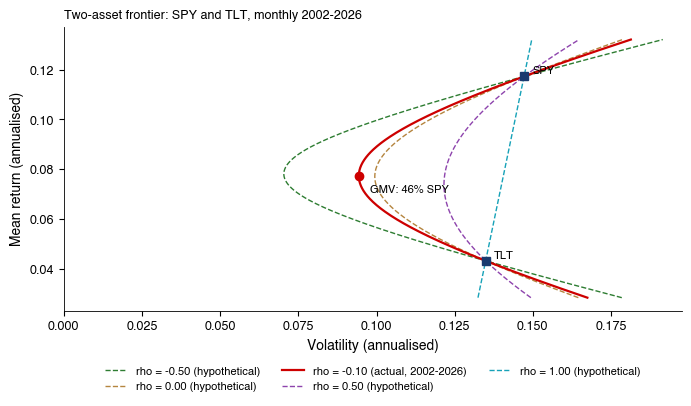

{'mu': {'SPY': 0.1172545143450236, 'TLT': 0.04324046691254241},
 'sd': {'SPY': 0.14718429473277003, 'TLT': 0.13490481664997114},
 'rho': np.float64(-0.10046543983276983),
 'w_gmv': np.float64(0.46050473691596405),
 'sd_gmv': np.float64(0.09433882133723462),
 'mu_gmv': np.float64(0.07732428635352284),
 'T': 288,
 'start': '2002-08-31',
 'end': '2026-07-31'}

In [4]:
def two_asset_stats():
    R, Rex, rf = us_monthly(['SPY', 'TLT'], start='2002-08-01')
    mu = R.mean() * 12
    sd = R.std() * np.sqrt(12)
    rho = R.corr().iloc[0, 1]
    return R, mu, sd, rho


def gmv_two(s1, s2, rho):
    """Weight of the first asset in the two-asset GMV portfolio."""
    return (s2 ** 2 - rho * s1 * s2) / (s1 ** 2 + s2 ** 2 - 2 * rho * s1 * s2)


def fig_two_asset():
    R, mu, sd, rho = two_asset_stats()
    w = np.linspace(-0.2, 1.2, 400)
    fig, ax = plt.subplots(figsize=(7, 4.2))
    for r, c in zip([-0.5, 0.0, rho, 0.5, 1.0], [Forest, Amber, IDAred, Purple, '#17A2B8']):
        m = w * mu['SPY'] + (1 - w) * mu['TLT']
        v = np.sqrt(w ** 2 * sd['SPY'] ** 2 + (1 - w) ** 2 * sd['TLT'] ** 2 + 2 * w * (1 - w) * r * sd['SPY'] * sd['TLT'])
        lab = f'rho = {r:.2f}' + (' (actual, 2002-2026)' if r == rho else ' (hypothetical)')
        ax.plot(v, m, color=c, lw=1.6 if r == rho else 1.0, ls='-' if r == rho else '--', label=lab)
    wg = gmv_two(sd['SPY'], sd['TLT'], rho)
    vg = np.sqrt(wg ** 2 * sd['SPY'] ** 2 + (1 - wg) ** 2 * sd['TLT'] ** 2 + 2 * wg * (1 - wg) * rho * sd['SPY'] * sd['TLT'])
    mg = wg * mu['SPY'] + (1 - wg) * mu['TLT']
    ax.plot(vg, mg, 'o', color=IDAred, ms=6)
    ax.annotate(f'GMV: {wg:.0%} SPY', (vg, mg), xytext=(8, -12), textcoords='offset points', fontsize=8)
    for s in ['SPY', 'TLT']:
        ax.plot(sd[s], mu[s], 's', color=MainBlue, ms=6)
        ax.annotate(s, (sd[s], mu[s]), xytext=(6, 2), textcoords='offset points', fontsize=8)
    ax.set_xlabel('Volatility (annualised)')
    ax.set_ylabel('Mean return (annualised)')
    ax.set_xlim(0, None)
    ax.set_title('Two-asset frontier: SPY and TLT, monthly 2002-2026', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.16)
    plt.tight_layout()
    save_fig('ch4_two_asset')
    return dict(mu=mu.to_dict(), sd=sd.to_dict(), rho=rho, w_gmv=wg, sd_gmv=vg, mu_gmv=mg,
                T=len(R), start=str(R.index[0].date()), end=str(R.index[-1].date()))


fig_two_asset()

## 2. The frontier of US sectors, with and without short sales

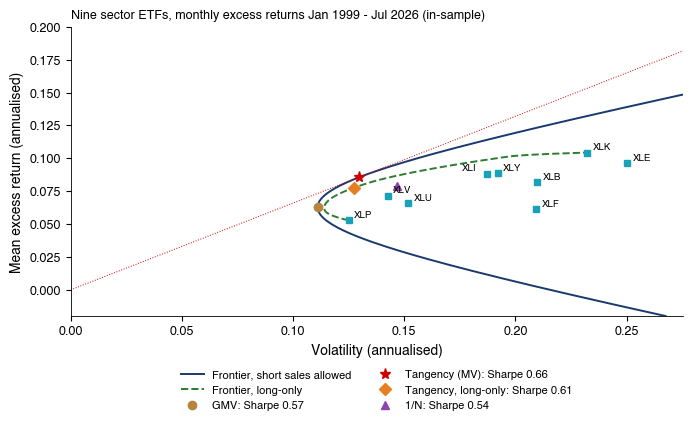

{'T': 331,
 'start': '1999-01-31',
 'end': '2026-07-31',
 'sharpe': {'gmv': np.float64(0.5652960476659711),
  'tan': np.float64(0.6596705337340462),
  'tan_lo': np.float64(0.6094606250329494),
  'ew': np.float64(0.5384938760649349)},
 'w_tan': {'XLB': np.float64(-0.2069641686150686),
  'XLE': np.float64(0.19403983345605622),
  'XLF': np.float64(-0.371793081663628),
  'XLI': np.float64(0.17883525969675615),
  'XLK': np.float64(0.12470334214884742),
  'XLP': np.float64(0.15511577340258262),
  'XLU': np.float64(0.2664941918046142),
  'XLV': np.float64(0.37175702824084067),
  'XLY': np.float64(0.28781182152899937)},
 'w_gmv': {'XLB': np.float64(-0.08596823270686252),
  'XLE': np.float64(0.06732279306549091),
  'XLF': np.float64(-0.05326041987318966),
  'XLI': np.float64(-0.16372096333327404),
  'XLK': np.float64(0.05649942526587134),
  'XLP': np.float64(0.5201175854117274),
  'XLU': np.float64(0.22674970479285878),
  'XLV': np.float64(0.3303152792428897),
  'XLY': np.float64(0.101944828134

In [5]:
def frontier_curve(mu, S, targets):
    """Analytical frontier (short sales allowed): sigma(m) for each target mean m."""
    Si = np.linalg.inv(S)
    one = np.ones(len(mu))
    A, B, C = one @ Si @ one, one @ Si @ mu, mu @ Si @ mu
    D = A * C - B ** 2
    return np.sqrt((A * targets ** 2 - 2 * B * targets + C) / D)


def frontier_lo(mu, S, targets):
    """Frontier with non-negative weights (SLSQP), for the attainable target means."""
    n = len(mu)
    out = []
    for m in targets:
        res = minimize(lambda w: w @ S @ w, np.ones(n) / n, method='SLSQP', bounds=[(0, 1)] * n,
                       constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1},
                                    {'type': 'eq', 'fun': lambda w, m=m: w @ mu - m}])
        out.append(np.sqrt(res.fun) if res.success else np.nan)
    return np.array(out)


def fig_frontier():
    R, Rex, rf = us_monthly(SECTORS)
    mu, S = Rex.mean().values * 12, Rex.cov().values * 12
    t = np.linspace(-0.02, 0.20, 200)
    s_u = frontier_curve(mu, S, t)
    t_lo = np.linspace(mu.min(), mu.max(), 60)
    s_lo = frontier_lo(mu, S, t_lo)
    wg, wt, wtl = w_gmv(S), w_tan(mu, S), w_long_only(S, mu)
    pt = lambda w: (np.sqrt(w @ S @ w), w @ mu)
    fig, ax = plt.subplots(figsize=(7, 4.4))
    ax.plot(s_u, t, color=MainBlue, lw=1.4, label='Frontier, short sales allowed')
    ax.plot(s_lo, t_lo, color=Forest, lw=1.4, ls='--', label='Frontier, long-only')
    for k, s in enumerate(SECTORS):
        ax.plot(np.sqrt(S[k, k]), mu[k], 's', color='#17A2B8', ms=4)
        ax.annotate(s, (np.sqrt(S[k, k]), mu[k]), xytext=(-18, 3) if s == 'XLI' else (4, 2),
                    textcoords='offset points', fontsize=7)
    for w, lab, c, mk in [(wg, 'GMV', Amber, 'o'), (wt, 'Tangency (MV)', IDAred, '*'),
                          (wtl, 'Tangency, long-only', Orange, 'D'), (w_ew(9), '1/N', Purple, '^')]:
        x, y = pt(w)
        ax.plot(x, y, mk, color=c, ms=8 if mk == '*' else 6, label=f'{lab}: Sharpe {y / x:.2f}')
    sm = max(np.sqrt(np.diag(S)).max(), pt(wt)[0]) * 1.1
    ax.plot([0, sm], [0, sm * pt(wt)[1] / pt(wt)[0]], color=IDAred, lw=0.7, ls=':')
    ax.set_xlim(0, sm)
    ax.set_ylim(-0.02, 0.2)
    ax.set_xlabel('Volatility (annualised)')
    ax.set_ylabel('Mean excess return (annualised)')
    ax.set_title(f'Nine sector ETFs, monthly excess returns {Rex.index[0]:%b %Y} - {Rex.index[-1]:%b %Y} (in-sample)',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save_fig('ch4_frontier')
    sr = lambda w: pt(w)[1] / pt(w)[0]
    return dict(T=len(Rex), start=str(Rex.index[0].date()), end=str(Rex.index[-1].date()),
                sharpe=dict(gmv=sr(wg), tan=sr(wt), tan_lo=sr(wtl), ew=sr(w_ew(9))),
                w_tan=dict(zip(SECTORS, wt)), w_gmv=dict(zip(SECTORS, wg)), w_tan_lo=dict(zip(SECTORS, wtl)),
                gmv_vol=pt(wg)[0], mu=dict(zip(SECTORS, mu)), vol=dict(zip(SECTORS, np.sqrt(np.diag(S)))))


fig_frontier()

## 3. The limits of Markowitz: estimation error and the 1/N benchmark

- Simulations with the sector sample moments as true parameters; returns from the Normal distribution.

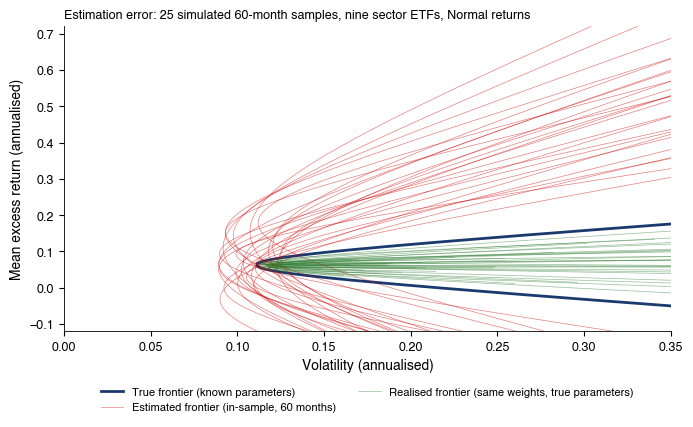

{'T': 60,
 'nsim': 2000,
 'sr_opt': np.float64(0.6596705337340462),
 'sr_ew': np.float64(0.5384938760649349),
 'share_B_negative': 0.113,
 'est_sr_median': 1.5646225225130446,
 'true_sr_median': 0.2999619323802991,
 'share_true_below_ew': 0.9625,
 'share_true_neg': 0.0755}

In [6]:
def sector_truth():
    """'True' parameters of the simulations: monthly mean and covariance of the full sample."""
    R, Rex, rf = us_monthly(SECTORS)
    return Rex.mean().values, Rex.cov().values


def fig_estimation_error(T=60, nsim=25, seed=SEED):
    mu, S = sector_truth()
    rng = np.random.default_rng(seed)
    t = np.linspace(-0.01, 0.06, 150) / 1          # monthly target means
    fig, ax = plt.subplots(figsize=(7, 4.4))
    s_true = frontier_curve(mu, S, t)
    ax.plot(s_true * np.sqrt(12), t * 12, color=MainBlue, lw=2, label='True frontier (known parameters)')
    est_sr, true_sr, neg_b = [], [], []
    for k in range(nsim):
        X = rng.multivariate_normal(mu, S, T)
        m_hat, S_hat = X.mean(0), np.cov(X.T)
        Si = np.linalg.inv(S_hat)
        one = np.ones(len(mu))
        s_hat = frontier_curve(m_hat, S_hat, t)
        # portfolios of the estimated frontier, evaluated with the true parameters
        A, B, C = one @ Si @ one, one @ Si @ m_hat, m_hat @ Si @ m_hat
        D = A * C - B ** 2
        real_m, real_s = [], []
        for m in t:
            lam, gam = (C - m * B) / D, (m * A - B) / D
            w = Si @ (lam * one + gam * m_hat)
            real_m.append(w @ mu)
            real_s.append(np.sqrt(w @ S @ w))
        ax.plot(s_hat * np.sqrt(12), t * 12, color=IDAred, lw=0.5, alpha=0.5,
                label='Estimated frontier (in-sample, 60 months)' if k == 0 else None)
        ax.plot(np.array(real_s) * np.sqrt(12), np.array(real_m) * 12, color=Forest, lw=0.5, alpha=0.5,
                label='Realised frontier (same weights, true parameters)' if k == 0 else None)
    for k in range(2000):
        X = rng.multivariate_normal(mu, S, T)
        m_hat, S_hat = X.mean(0), np.cov(X.T)
        w = w_tan(m_hat, S_hat)
        est_sr.append((w @ m_hat) / np.sqrt(w @ S_hat @ w) * np.sqrt(12))   # = sign(B) theta_hat
        neg_b.append(np.linalg.solve(S_hat, m_hat).sum() < 0)
        true_sr.append((w @ mu) / np.sqrt(w @ S @ w) * np.sqrt(12))
    wt = w_tan(mu, S)
    sr_opt = (wt @ mu) / np.sqrt(wt @ S @ wt) * np.sqrt(12)
    we = w_ew(len(mu))
    sr_ew = (we @ mu) / np.sqrt(we @ S @ we) * np.sqrt(12)
    ax.set_xlim(0, 0.35)
    ax.set_ylim(-0.12, 0.72)
    ax.set_xlabel('Volatility (annualised)')
    ax.set_ylabel('Mean excess return (annualised)')
    ax.set_title('Estimation error: 25 simulated 60-month samples, nine sector ETFs, Normal returns',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.15)
    plt.tight_layout()
    save_fig('ch4_estimation_error')
    # theta_hat = |in-sample Sharpe| = square root of mu' S^-1 mu (estimated maximum Sharpe, Kan & Zhou 2007)
    est_sr, true_sr = np.abs(np.array(est_sr)), np.array(true_sr)
    return dict(T=T, nsim=2000, sr_opt=sr_opt, sr_ew=sr_ew, share_B_negative=float(np.mean(neg_b)),
                est_sr_median=float(np.median(est_sr)), true_sr_median=float(np.median(true_sr)),
                share_true_below_ew=float(np.mean(true_sr < sr_ew)), share_true_neg=float(np.mean(true_sr < 0)))


fig_estimation_error()

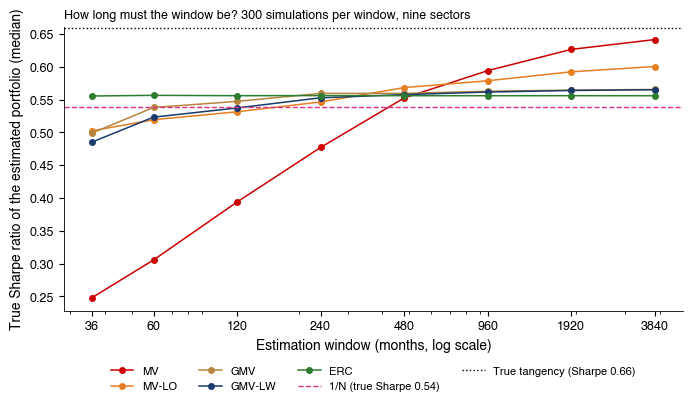

{'Ts': [36, 60, 120, 240, 480, 960, 1920, 3840],
 'median_true_sr': {'MV': {'36': np.float64(0.24820236261009215),
   '60': np.float64(0.30559684205007276),
   '120': np.float64(0.393919095995256),
   '240': np.float64(0.4770517531790528),
   '480': np.float64(0.5524062447451136),
   '960': np.float64(0.593993144689862),
   '1920': np.float64(0.6263801986203466),
   '3840': np.float64(0.6413536251409315)},
  'MV-LO': {'36': np.float64(0.5022293749402433),
   '60': np.float64(0.5192180070776619),
   '120': np.float64(0.5313480695110653),
   '240': np.float64(0.546300250398492),
   '480': np.float64(0.5681859392807012),
   '960': np.float64(0.5785817083110698),
   '1920': np.float64(0.5922267574796061),
   '3840': np.float64(0.6002874469219)},
  'GMV': {'36': np.float64(0.49887235657428697),
   '60': np.float64(0.5378984250888984),
   '120': np.float64(0.5471780851634146),
   '240': np.float64(0.5594014576368116),
   '480': np.float64(0.5593293784370212),
   '960': np.float64(0.562664383

In [7]:
def fig_window_length(nsim=300, seed=SEED):
    mu, S = sector_truth()
    n = len(mu)
    rng = np.random.default_rng(seed)
    Ts = [36, 60, 120, 240, 480, 960, 1920, 3840]
    names = ['MV', 'MV-LO', 'GMV', 'GMV-LW', 'ERC']
    res = {k: [] for k in names}
    true_sr = lambda w: (w @ mu) / np.sqrt(w @ S @ w) * np.sqrt(12)
    for T in Ts:
        vals = {k: [] for k in names}
        for i in range(nsim):
            X = rng.multivariate_normal(mu, S, T)
            for k in names:
                vals[k].append(true_sr(weights(k, X)))
        for k in names:
            res[k].append(np.median(vals[k]))
    sr_ew = true_sr(w_ew(n))
    sr_opt = true_sr(w_tan(mu, S))
    fig, ax = plt.subplots(figsize=(7, 4.2))
    for k in names:
        ax.plot(Ts, res[k], 'o-', color=SCOL[k], ms=4, label=k)
    ax.axhline(sr_ew, color=EWcol, ls='--', lw=1, label=f'1/N (true Sharpe {sr_ew:.2f})')
    ax.axhline(sr_opt, color='black', ls=':', lw=1, label=f'True tangency (Sharpe {sr_opt:.2f})')
    ax.set_xscale('log')
    ax.set_xticks(Ts, [str(T) for T in Ts])
    ax.set_xlabel('Estimation window (months, log scale)')
    ax.set_ylabel('True Sharpe ratio of the estimated portfolio (median)')
    ax.set_title(f'How long must the window be? {nsim} simulations per window, nine sectors', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.16)
    plt.tight_layout()
    save_fig('ch4_window_length')
    cross = next((T for T, v in zip(Ts, res['MV']) if v > sr_ew), None)
    return dict(Ts=Ts, median_true_sr={k: dict(zip(map(str, Ts), v)) for k, v in res.items()},
                sr_ew=sr_ew, sr_opt=sr_opt, mv_beats_ew_at=cross)


fig_window_length(nsim=300)

## 4. Covariance shrinkage (Ledoit–Wolf)

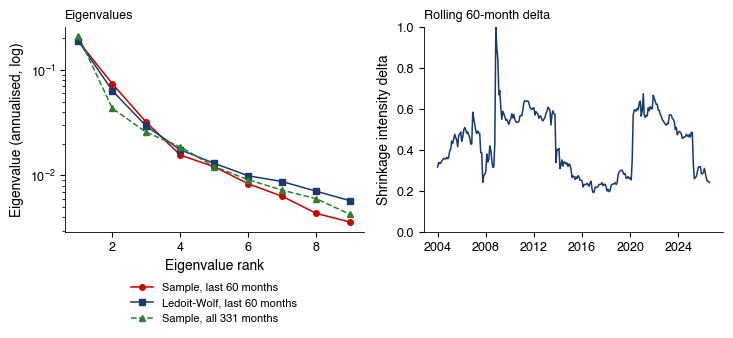

{'delta_last': np.float64(0.23984627231136196),
 'delta_mean': np.float64(0.43295242844134224),
 'delta_min': 0.19061562037268706,
 'delta_max': 1.0,
 'cond_sample': np.float64(51.59165848731628),
 'cond_lw': np.float64(32.46524707484896),
 'cond_full': np.float64(48.70864588697877),
 'ev_sample': [0.18610017403498463,
  0.07347968865066128,
  0.03177592599516837,
  0.015575847731240348,
  0.012067658064428171,
  0.008330621415441,
  0.006337858086958281,
  0.004376076253975444,
  0.003607175646054035],
 'ev_lw': [0.187086808132558,
  0.06331912705294206,
  0.029244161503560722,
  0.017486658738232286,
  0.013010035738811623,
  0.009911476132074024,
  0.008745761065985215,
  0.007084318188721737,
  0.005762679326025985],
 'ev_full': [0.2080462025103107,
  0.04308549059878002,
  0.025573136718565773,
  0.01866025767070133,
  0.012107258728035449,
  0.009098799458153934,
  0.007245634008769222,
  0.00601938201325471,
  0.00427123765651483],
 'end': '2026-07-31'}

In [8]:
def fig_shrinkage():
    R, Rex, rf = us_monthly(SECTORS)
    X = Rex.values
    last = X[-WINDOW:]
    S = np.cov(last.T, bias=True)
    Slw, d_last = lw_cc(last)
    Sfull = np.cov(X.T, bias=True)
    ev = lambda A: np.sort(np.linalg.eigvalsh(A))[::-1] * 12
    deltas = pd.Series([lw_cc(X[t - WINDOW:t])[1] for t in range(WINDOW, len(X) + 1)],
                       index=Rex.index[WINDOW - 1:])
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.6))
    k = np.arange(1, 10)
    axes[0].plot(k, ev(S), 'o-', color=IDAred, ms=4, label='Sample, last 60 months')
    axes[0].plot(k, ev(Slw), 's-', color=MainBlue, ms=4, label='Ledoit-Wolf, last 60 months')
    axes[0].plot(k, ev(Sfull), '^--', color=Forest, ms=4, label=f'Sample, all {len(X)} months')
    axes[0].set_yscale('log')
    axes[0].set_xlabel('Eigenvalue rank')
    axes[0].set_ylabel('Eigenvalue (annualised, log)')
    axes[0].set_title('Eigenvalues', fontsize=9, loc='left')
    legend_outside_bottom(axes[0], ncol=1, y=-0.2)
    axes[1].plot(deltas.index, deltas.values, color=MainBlue)
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel('Shrinkage intensity delta')
    axes[1].set_title('Rolling 60-month delta', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch4_shrinkage')
    cond = lambda A: np.linalg.cond(A)
    return dict(delta_last=d_last, delta_mean=deltas.mean(), delta_min=deltas.min(), delta_max=deltas.max(),
                cond_sample=cond(S), cond_lw=cond(Slw), cond_full=cond(Sfull),
                ev_sample=ev(S).tolist(), ev_lw=ev(Slw).tolist(), ev_full=ev(Sfull).tolist(),
                end=str(Rex.index[-1].date()))


fig_shrinkage()

## 5. Black–Litterman: one relative view on sectors

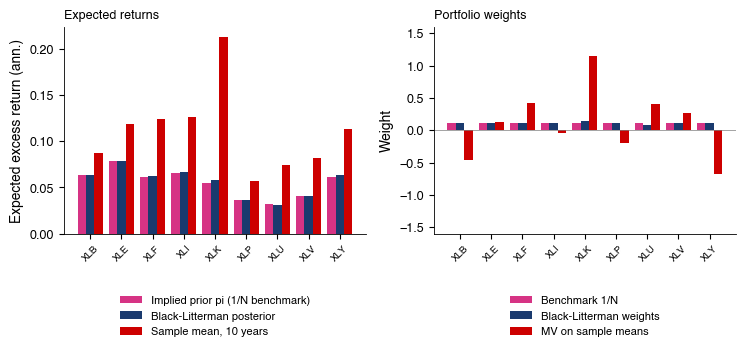

{'start': '2016-08-31',
 'end': '2026-07-31',
 'T': 120,
 'delta': 2.5,
 'tau': 0.05,
 'view': 'XLK - XLU = 3% p.a.',
 'prior_view': 0.02218123990657088,
 'post_view': 0.026090619953285432,
 'pi': {'XLB': np.float64(0.0629260312301894),
  'XLE': np.float64(0.07823924037050137),
  'XLF': np.float64(0.061516929771488794),
  'XLI': np.float64(0.06518624437079529),
  'XLK': np.float64(0.05475265838040866),
  'XLP': np.float64(0.036066479631737515),
  'XLU': np.float64(0.03257141847383778),
  'XLV': np.float64(0.04032569268360592),
  'XLY': np.float64(0.06150130690056855)},
 'mu_bl': {'XLB': np.float64(0.06347035965045082),
  'XLE': np.float64(0.07874395907333276),
  'XLF': np.float64(0.06242311595208663),
  'XLI': np.float64(0.06612430976935126),
  'XLK': np.float64(0.05753403594804175),
  'XLP': np.float64(0.03593120847665053),
  'XLU': np.float64(0.031443415994756314),
  'XLV': np.float64(0.04062297757492034),
  'XLY': np.float64(0.06334067599888832)},
 'mu_sample': {'XLB': np.float64(0.

In [9]:
def black_litterman(Sigma, w_b, P, q, delta=2.5, tau=0.05, conf=None):
    """Black-Litterman (1992), He-Litterman form: Omega = diag(P tau Sigma P') if not given."""
    pi = delta * Sigma @ w_b
    Om = np.diag(np.diag(P @ (tau * Sigma) @ P.T)) if conf is None else conf
    A = np.linalg.inv(tau * Sigma) + P.T @ np.linalg.inv(Om) @ P
    mu_bl = np.linalg.solve(A, np.linalg.inv(tau * Sigma) @ pi + P.T @ np.linalg.inv(Om) @ q)
    w_bl = np.linalg.solve(delta * Sigma, mu_bl)
    return pi, mu_bl, w_bl


def fig_black_litterman():
    R, Rex, rf = us_monthly(SECTORS, start='2016-08-01')
    Sigma = Rex.cov().values * 12
    n = len(SECTORS)
    w_b = w_ew(n)
    P = np.zeros((1, n))
    P[0, SECTORS.index('XLK')], P[0, SECTORS.index('XLU')] = 1, -1
    q = np.array([0.03])
    pi, mu_bl, w_bl = black_litterman(Sigma, w_b, P, q)
    mu_s = Rex.mean().values * 12
    w_s = w_tan(mu_s, Sigma)
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8))
    x = np.arange(n)
    axes[0].bar(x - 0.27, pi, 0.27, color=EWcol, label='Implied prior pi (1/N benchmark)')
    axes[0].bar(x, mu_bl, 0.27, color=MainBlue, label='Black-Litterman posterior')
    axes[0].bar(x + 0.27, mu_s, 0.27, color=IDAred, label='Sample mean, 10 years')
    axes[0].set_xticks(x, SECTORS, rotation=45, fontsize=7)
    axes[0].set_ylabel('Expected excess return (ann.)')
    axes[0].set_title('Expected returns', fontsize=9, loc='left')
    legend_outside_bottom(axes[0], ncol=1, y=-0.25)
    axes[1].bar(x - 0.27, w_b, 0.27, color=EWcol, label='Benchmark 1/N')
    axes[1].bar(x, w_bl, 0.27, color=MainBlue, label='Black-Litterman weights')
    axes[1].bar(x + 0.27, w_s, 0.27, color=IDAred, label='MV on sample means')
    axes[1].axhline(0, color=Gray, lw=0.5)
    axes[1].set_xticks(x, SECTORS, rotation=45, fontsize=7)
    axes[1].set_ylim(-1.6, 1.6)
    axes[1].set_ylabel('Weight')
    axes[1].set_title('Portfolio weights', fontsize=9, loc='left')
    legend_outside_bottom(axes[1], ncol=1, y=-0.25)
    plt.tight_layout()
    save_fig('ch4_black_litterman')
    return dict(start=str(Rex.index[0].date()), end=str(Rex.index[-1].date()), T=len(Rex), delta=2.5, tau=0.05,
                view='XLK - XLU = 3% p.a.', prior_view=(P @ pi).item(), post_view=(P @ mu_bl).item(),
                pi=dict(zip(SECTORS, pi)), mu_bl=dict(zip(SECTORS, mu_bl)), mu_sample=dict(zip(SECTORS, mu_s)),
                w_bl=dict(zip(SECTORS, w_bl)), w_sample_mv=dict(zip(SECTORS, w_s)),
                w_bl_sum=float(w_bl.sum()))


fig_black_litterman()

## 6. Risk parity and Hierarchical Risk Parity

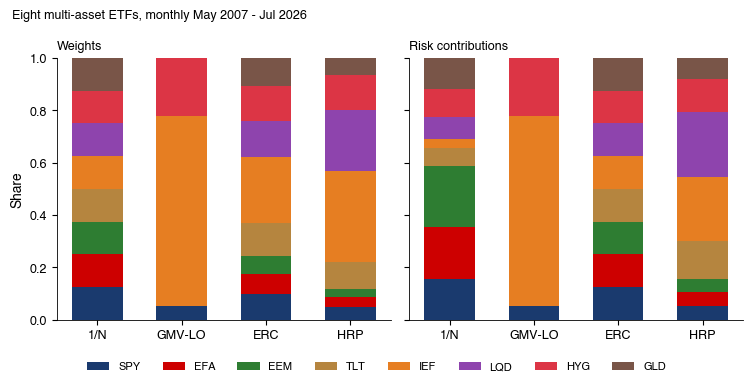

{'1/N': {'w': {'SPY': np.float64(0.125),
   'EFA': np.float64(0.125),
   'EEM': np.float64(0.125),
   'TLT': np.float64(0.125),
   'IEF': np.float64(0.125),
   'LQD': np.float64(0.125),
   'HYG': np.float64(0.125),
   'GLD': np.float64(0.125)},
  'rc': {'SPY': np.float64(0.15742401677889428),
   'EFA': np.float64(0.19496263503006858),
   'EEM': np.float64(0.23418951897865534),
   'TLT': np.float64(0.06788552619819219),
   'IEF': np.float64(0.03553673033247813),
   'LQD': np.float64(0.08600817929053724),
   'HYG': np.float64(0.10670428542809304),
   'GLD': np.float64(0.11728910796308115)},
  'vol': 0.09417785644005897,
  'rc_equity': 0.6932804562157113},
 'GMV-LO': {'w': {'SPY': np.float64(0.05196143603153195),
   'EFA': np.float64(0.0),
   'EEM': np.float64(1.013354109004409e-18),
   'TLT': np.float64(6.482788333378806e-17),
   'IEF': np.float64(0.7259336380626622),
   'LQD': np.float64(6.773757097955044e-17),
   'HYG': np.float64(0.22210492590580558),
   'GLD': np.float64(4.4229287002

In [10]:
def fig_risk_contrib():
    R, Rex, rf = us_monthly(MULTI)
    S = Rex.cov().values * 12
    ws = {'1/N': w_ew(len(MULTI)), 'GMV-LO': w_long_only(S), 'ERC': w_erc(S), 'HRP': w_hrp(S)}
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8), sharey=True)
    for ax, what in zip(axes, ['Weights', 'Risk contributions']):
        bottom = np.zeros(len(ws))
        for k, a in enumerate(MULTI):
            vals = np.array([w[k] if what == 'Weights' else risk_contrib(w, S)[k] for w in ws.values()])
            ax.bar(list(ws), vals, bottom=bottom, color=PALETTE[k], label=a, width=0.6)
            bottom += vals
        ax.set_title(what, fontsize=9, loc='left')
        ax.set_ylim(0, 1)
    axes[0].set_ylabel('Share')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=8, frameon=False)
    plt.suptitle(f'Eight multi-asset ETFs, monthly {Rex.index[0]:%b %Y} - {Rex.index[-1]:%b %Y}', fontsize=9, x=0.02, ha='left')
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    save_fig('ch4_risk_contrib')
    out = {}
    for k, w in ws.items():
        rc = risk_contrib(w, S)
        out[k] = dict(w=dict(zip(MULTI, w)), rc=dict(zip(MULTI, rc)), vol=float(np.sqrt(w @ S @ w)),
                      rc_equity=float(rc[:3].sum() + rc[MULTI.index('HYG')]))
    out['vol'] = dict(zip(MULTI, np.sqrt(np.diag(S))))
    out['T'] = len(Rex)
    return out


fig_risk_contrib()

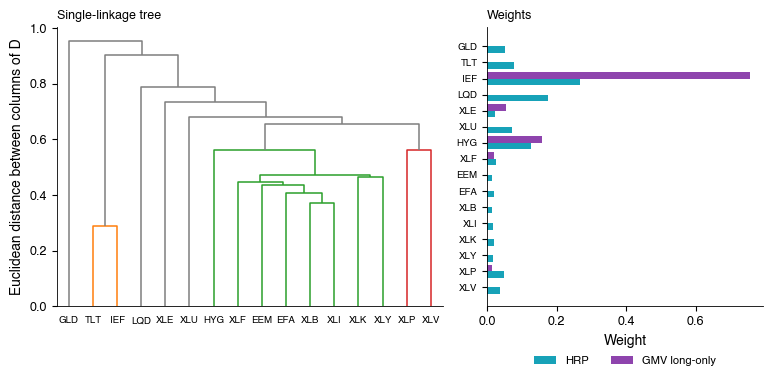

{'order': ['GLD',
  'TLT',
  'IEF',
  'LQD',
  'XLE',
  'XLU',
  'HYG',
  'XLF',
  'EEM',
  'EFA',
  'XLB',
  'XLI',
  'XLK',
  'XLY',
  'XLP',
  'XLV'],
 'merges': [{'a': ['TLT', 'IEF'], 'height': 0.2902682617279315},
  {'a': ['XLB', 'XLI'], 'height': 0.37147543182330517},
  {'a': ['EFA'], 'height': 0.40931137960488556},
  {'a': ['EEM'], 'height': 0.4352201935139159},
  {'a': ['XLF'], 'height': 0.445910543771722},
  {'a': ['XLK', 'XLY'], 'height': 0.46385325076391065},
  {'a': [], 'height': 0.47419511886673765},
  {'a': ['HYG'], 'height': 0.5621821192237648},
  {'a': ['XLP', 'XLV'], 'height': 0.5634155024745299},
  {'a': [], 'height': 0.6541480009271499},
  {'a': ['XLU'], 'height': 0.6800622002231406},
  {'a': ['XLE'], 'height': 0.7342964668143724},
  {'a': ['LQD'], 'height': 0.7892609408820962},
  {'a': [], 'height': 0.9053660648146228},
  {'a': ['GLD'], 'height': 0.9554188945245098}],
 'last_single': ['GLD'],
 'first_pair': {'a': ['TLT', 'IEF'], 'height': 0.2902682617279315},
 'w_hr

In [11]:
def fig_hrp():
    R, Rex, rf = us_monthly(COMBINED)
    S = Rex.cov().values * 12
    Z = hrp_tree(S)
    w = w_hrp(S)
    fig, axes = plt.subplots(1, 2, figsize=(7.8, 3.9), gridspec_kw={'width_ratios': [1.4, 1]})
    dn = dendrogram(Z, labels=COMBINED, ax=axes[0], color_threshold=0.6 * Z[:, 2].max(), above_threshold_color=Gray,
                    leaf_font_size=7)
    axes[0].set_ylabel('Euclidean distance between columns of D')
    axes[0].set_title('Single-linkage tree', fontsize=9, loc='left')
    order = dn['ivl']
    wi = pd.Series(w, index=COMBINED)[order]
    wg = pd.Series(w_long_only(S), index=COMBINED)[order]
    y = np.arange(len(order))
    axes[1].barh(y + 0.2, wi.values, 0.4, color='#17A2B8', label='HRP')
    axes[1].barh(y - 0.2, wg.values, 0.4, color=Purple, label='GMV long-only')
    axes[1].set_yticks(y, order, fontsize=7)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Weight')
    axes[1].set_title('Weights', fontsize=9, loc='left')
    legend_outside_bottom(axes[1], ncol=2, y=-0.14)
    plt.tight_layout()
    save_fig('ch4_hrp')
    merges = [dict(a=[COMBINED[int(i)] for i in (Z[k, 0], Z[k, 1]) if i < len(COMBINED)], height=float(Z[k, 2]))
              for k in range(len(Z))]
    last = [COMBINED[int(i)] for i in Z[-1, :2] if i < len(COMBINED)]
    return dict(order=order, merges=merges, last_single=last, first_pair=merges[0],
                w_hrp=dict(zip(COMBINED, w)), w_gmv_lo=dict(zip(COMBINED, w_long_only(S))),
                n_nonzero_gmv_lo=int((w_long_only(S) > 1e-4).sum()), T=len(Rex),
                start=str(Rex.index[0].date()))


fig_hrp()

## 7. Out-of-sample evaluation on three universes

- Sectors: OOS January 2004 – July 2026; multi-asset and combined: May 2012 – July 2026.

In [12]:
def run_backtests():
    out = {}
    for name, syms in UNIVERSES.items():
        R, Rex, rf = us_monthly(syms)
        out[name] = backtest(R, Rex)
        print(f'   backtest {name}: {len(out[name][0])} months')
    return out


SUMCOLS = {'mean': 'Mean', 'vol': 'Volatility', 'sharpe': 'Sharpe', 'turnover': 'Turnover', 'mdd': 'Max drawdown', 'sharpe_10bp': 'Sharpe net 10 bp', 'sharpe_50bp': 'Sharpe net 50 bp'}
bts = run_backtests()
tabs = {}
for u, (ret, to, W) in bts.items():
    t = summary(ret, to)
    t.attrs = dict(start=f'{ret.index[0]:%Y-%m}', end=f'{ret.index[-1]:%Y-%m}')
    tabs[u] = t
    print(f"{u}: out of sample {t.attrs['start']} – {t.attrs['end']}")
    print(t.rename(columns=SUMCOLS).round(3), '\n')

   backtest Sectors: 271 months


   backtest Multi-asset: 171 months


   backtest Combined: 171 months
Sectors: out of sample 2004-01 – 2026-07
         Mean  Volatility  Sharpe  Turnover  Max drawdown  Sharpe net 10 bp  \
1/N     0.094       0.143   0.661     0.024        -0.491             0.659   
MV      0.178       0.690   0.258     3.855        -1.000             0.194   
MV-LO   0.107       0.147   0.724     0.235        -0.423             0.705   
GMV     0.085       0.119   0.711     0.234        -0.326             0.687   
GMV-LO  0.081       0.115   0.700     0.087        -0.343             0.691   
GMV-LW  0.076       0.118   0.645     0.137        -0.311             0.632   
ERC     0.093       0.132   0.699     0.028        -0.467             0.696   
HRP     0.089       0.128   0.700     0.082        -0.452             0.692   

        Sharpe net 50 bp  
1/N                0.651  
MV                -0.080  
MV-LO              0.629  
GMV                0.594  
GMV-LO             0.654  
GMV-LW             0.576  
ERC                0.686 

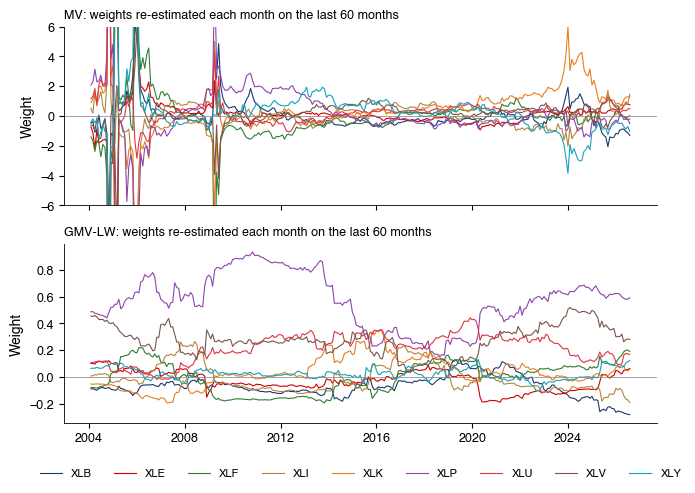

Windows: 271; windows with 1' S^-1 mu < 0: 12
MV: largest absolute weight 26.08, median gross exposure 4.86, share of months with gross exposure > 3 90.4%
GMV-LW: largest absolute weight 0.94, median gross exposure 1.50


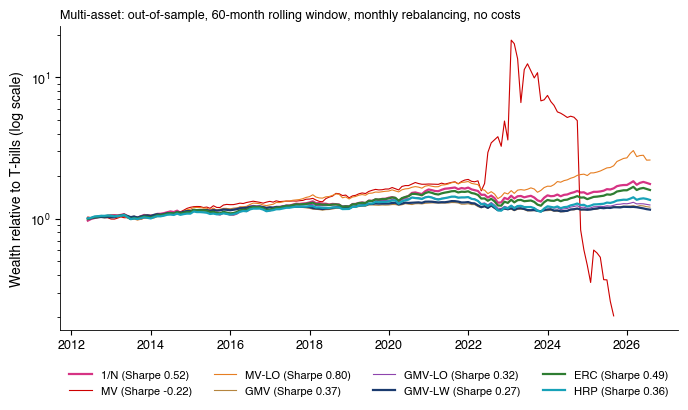

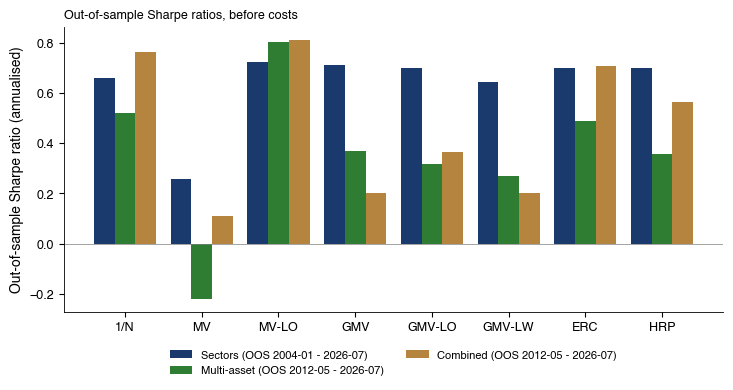

In [13]:
def fig_rolling_weights(bt):
    ret, to, W = bt
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 5.0), sharex=True)
    for ax, s in zip(axes, ['MV', 'GMV-LW']):
        for k, c in enumerate(W[s].columns):
            ax.plot(W[s].index, W[s][c], color=PALETTE[k % len(PALETTE)], lw=0.8, label=c)
        ax.axhline(0, color=Gray, lw=0.5)
        ax.set_ylabel('Weight')
        ax.set_title(f'{s}: weights re-estimated each month on the last 60 months', fontsize=9, loc='left')
    axes[0].set_ylim(-6, 6)
    legend_outside_bottom(axes[1], ncol=9, y=-0.2)
    plt.tight_layout()
    save_fig('ch4_rolling_weights')
    mv, lw = W['MV'], W['GMV-LW']
    X = us_monthly(list(W['MV'].columns))[1].values
    B = np.array([np.linalg.solve(np.cov(X[t - WINDOW:t].T), X[t - WINDOW:t].mean(0)).sum()
                  for t in range(WINDOW, len(X))])                      # 1' S^-1 mu in each window
    return dict(n_windows=len(B), n_B_negative=int((B < 0).sum()),
                mv_max_abs=float(mv.abs().max().max()), mv_median_gross=float(mv.abs().sum(1).median()),
                lw_max_abs=float(lw.abs().max().max()), lw_median_gross=float(lw.abs().sum(1).median()),
                mv_share_months_gross_gt3=float((mv.abs().sum(1) > 3).mean()))


def fig_oos_cum(bts, universe='Multi-asset'):
    ret, to, W = bts[universe]
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for s in STRATS:
        rf = ret.attrs['rf']
        total = ret[s] + rf                                       # total return of the portfolio
        wealth = np.cumprod(1 + total) / np.cumprod(1 + rf)       # wealth relative to the T-bill account
        ruin = np.flatnonzero(total.values <= -1)                 # a loss >= 100% wipes out wealth
        if len(ruin):
            wealth.iloc[ruin[0]:] = np.nan                        # the path stops at ruin
        ax.plot(ret.index, wealth, color=SCOL[s], lw=1.6 if s in ('1/N', 'GMV-LW', 'ERC', 'HRP') else 0.8,
                label=f'{s} (Sharpe {sharpe(ret[s]):.2f})')
    ax.set_yscale('log')
    ax.set_ylabel('Wealth relative to T-bills (log scale)')
    ax.set_title(f'{universe}: out-of-sample, 60-month rolling window, monthly rebalancing, no costs',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.1)
    plt.tight_layout()
    save_fig('ch4_oos_cum')


def fig_oos_sharpe(tabs):
    fig, ax = plt.subplots(figsize=(7.4, 4.0))
    x = np.arange(len(STRATS))
    wd = 0.27
    for k, (u, c) in enumerate(zip(UNIVERSES, [MainBlue, Forest, Amber])):
        v = tabs[u].loc[STRATS, 'sharpe'].values
        ax.bar(x + (k - 1) * wd, v, wd, color=c, label=f'{u} (OOS {tabs[u].attrs["start"]} - {tabs[u].attrs["end"]})')
    ax.axhline(0, color=Gray, lw=0.5)
    ax.set_xticks(x, STRATS)
    ax.set_ylabel('Out-of-sample Sharpe ratio (annualised)')
    ax.set_title('Out-of-sample Sharpe ratios, before costs', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=2, y=-0.1)
    plt.tight_layout()
    save_fig('ch4_oos_sharpe')


rw = fig_rolling_weights(bts['Sectors'])
print(f"Windows: {rw['n_windows']}; windows with 1' S^-1 mu < 0: {rw['n_B_negative']}")
print(f"MV: largest absolute weight {rw['mv_max_abs']:.2f}, median gross exposure {rw['mv_median_gross']:.2f}, "
      f"share of months with gross exposure > 3 {rw['mv_share_months_gross_gt3']:.1%}")
print(f"GMV-LW: largest absolute weight {rw['lw_max_abs']:.2f}, median gross exposure {rw['lw_median_gross']:.2f}")
fig_oos_cum(bts)
fig_oos_sharpe(tabs)

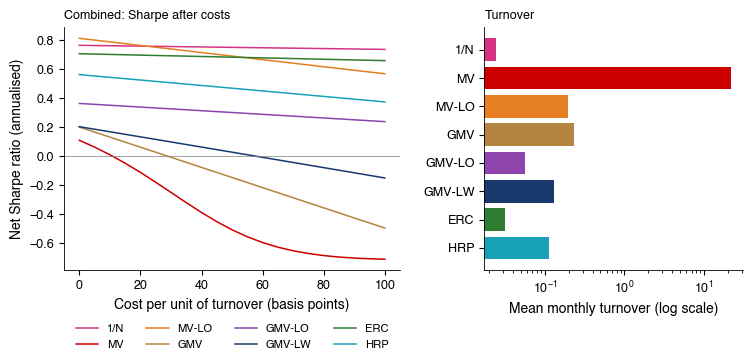

In [14]:
def fig_costs(bts, universe='Combined'):
    ret, to, W = bts[universe]
    c = np.arange(0, 101, 5)
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.8), gridspec_kw={'width_ratios': [1.3, 1]})
    for s in STRATS:
        axes[0].plot(c, [sharpe(ret[s] - cc / 1e4 * to[s].fillna(0)) for cc in c], color=SCOL[s], label=s)
    axes[0].set_xlabel('Cost per unit of turnover (basis points)')
    axes[0].set_ylabel('Net Sharpe ratio (annualised)')
    axes[0].set_title(f'{universe}: Sharpe after costs', fontsize=9, loc='left')
    axes[0].axhline(0, color=Gray, lw=0.5)
    legend_outside_bottom(axes[0], ncol=4, y=-0.18)
    tv = to[STRATS].mean()
    axes[1].barh(STRATS, tv.values, color=[SCOL[s] for s in STRATS])
    axes[1].set_xscale('log')
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Mean monthly turnover (log scale)')
    axes[1].set_title('Turnover', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch4_costs')


fig_costs(bts)

- Block lengths: Algorithm 3.1 of Ledoit–Wolf (2008); the cell below calibrates one pair (ERC versus 1/N, multi-asset), and the table uses the block lengths already calibrated for all 21 pairs.

Calibrated block length, ERC vs 1/N (multi-asset): 10
Coverage of the 95% interval by block length: {'1': 0.918, '2': 0.923, '4': 0.928, '6': 0.932, '8': 0.94, '10': 0.944}


Sectors: each rule minus 1/N
        Sharpe difference  p HAC  p bootstrap  Block length
MV                 -0.404  0.223        0.296           6.0
MV-LO               0.063  0.597        0.627           1.0
GMV                 0.050  0.754        0.762           1.0
GMV-LO              0.039  0.726        0.733           1.0
GMV-LW             -0.015  0.926        0.938           1.0
ERC                 0.038  0.091        0.130           1.0
HRP                 0.039  0.325        0.361           1.0 

Multi-asset: each rule minus 1/N
        Sharpe difference  p HAC  p bootstrap  Block length
MV                 -0.739  0.014        0.057          10.0
MV-LO               0.286  0.119        0.159          10.0
GMV                -0.148  0.511        0.536           1.0
GMV-LO             -0.202  0.140        0.146           8.0
GMV-LW             -0.248  0.194        0.202           4.0
ERC                -0.031  0.612        0.585          10.0
HRP                -0.161  0.072    

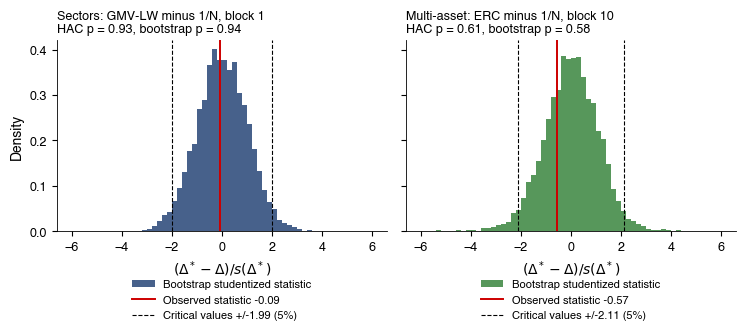

{'Sectors': {'strategy': 'GMV-LW',
  'diff': np.float64(-0.015361314368660395),
  'se_hac': np.float64(0.16580004404044116),
  'p_hac': np.float64(0.9261819064106698),
  'ci_boot': [np.float64(-0.3600245000017952), np.float64(0.3293018712644744)],
  'p_boot': 0.9376,
  'block': 1,
  'calibration': None,
  'se_qs': np.float64(0.17317331811924014),
  't_obs': -0.08870485670363615,
  'z_star': 1.9902788107103986},
 'Multi-asset': {'strategy': 'ERC',
  'diff': np.float64(-0.03071333013495971),
  'se_hac': np.float64(0.060485265878214546),
  'p_hac': np.float64(0.6116062245569931),
  'ci_boot': [np.float64(-0.14508546606963307),
   np.float64(0.08365880579971366)],
  'p_boot': 0.5848,
  'block': 10,
  'calibration': None,
  'se_qs': np.float64(0.05408554983636567),
  't_obs': -0.5678657280527246,
  'z_star': 2.114652366125575}}

In [15]:
BLOCKS = {('Sectors', 'MV'): 6, ('Sectors', 'MV-LO'): 1, ('Sectors', 'GMV'): 1, ('Sectors', 'GMV-LO'): 1, ('Sectors', 'GMV-LW'): 1, ('Sectors', 'ERC'): 1, ('Sectors', 'HRP'): 1, ('Multi-asset', 'MV'): 10, ('Multi-asset', 'MV-LO'): 10, ('Multi-asset', 'GMV'): 1, ('Multi-asset', 'GMV-LO'): 8, ('Multi-asset', 'GMV-LW'): 4, ('Multi-asset', 'ERC'): 10, ('Multi-asset', 'HRP'): 6, ('Combined', 'MV'): 10, ('Combined', 'MV-LO'): 10, ('Combined', 'GMV'): 1, ('Combined', 'GMV-LO'): 6, ('Combined', 'GMV-LW'): 2, ('Combined', 'ERC'): 10, ('Combined', 'HRP'): 8}
def sharpe_tests(bts, bench='1/N', n_jobs=1, blocks=None):
    """All rules against 1/N in the three universes; returns the results and the bootstrap statistics.
    blocks: {(universe, rule): block} from an earlier calibration (optional)."""
    pairs = {(u, s): (bts[u][0][s], bts[u][0][bench]) for u in bts for s in STRATS if s != bench}
    res = run_tests(pairs, n_jobs, blocks)
    out = {u: {s: res[(u, s)][0] for s in STRATS if s != bench} for u in bts}
    draws = {k: v[1] for k, v in res.items()}
    return out, draws


def fig_sharpe_test(tests, draws):
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6), sharey=True)
    res = {}
    for ax, (u, s) in zip(axes, [('Sectors', 'GMV-LW'), ('Multi-asset', 'ERC')]):
        r = tests[u][s]
        ts = draws[(u, s)]
        ax.hist(ts, bins=np.linspace(-6, 6, 61), color=SCOL[s], alpha=0.8, density=True,
                label='Bootstrap studentized statistic')
        ax.axvline(r['t_obs'], color=IDAred, lw=1.4, label=f"Observed statistic {r['t_obs']:+.2f}")
        ax.axvline(-r['z_star'], color='black', ls='--', lw=0.8, label=f"Critical values +/-{r['z_star']:.2f} (5%)")
        ax.axvline(r['z_star'], color='black', ls='--', lw=0.8)
        ax.set_title(f"{u}: {s} minus 1/N, block {r['block']}\nHAC p = {r['p_hac']:.2f}, bootstrap p = {r['p_boot']:.2f}",
                     fontsize=9, loc='left')
        ax.set_xlabel(r'$(\Delta^* - \Delta)/s(\Delta^*)$')
        legend_outside_bottom(ax, ncol=1, y=-0.2)
        res[u] = dict(strategy=s, **r)
    axes[0].set_ylabel('Density')
    plt.tight_layout()
    save_fig('ch4_sharpe_test')
    return res


b_cal, cover = lw_block_calibration(bts['Multi-asset'][0]['ERC'].values, bts['Multi-asset'][0]['1/N'].values)
print(f'Calibrated block length, ERC vs 1/N (multi-asset): {b_cal}')
print('Coverage of the 95% interval by block length:', {k: round(v, 3) for k, v in cover.items()})
tests, draws = sharpe_tests(bts, blocks=BLOCKS)
TESTCOLS = {'diff': 'Sharpe difference', 'p_hac': 'p HAC', 'p_boot': 'p bootstrap', 'block': 'Block length'}
for u, d in tests.items():
    print(f'{u}: each rule minus 1/N')
    print(pd.DataFrame(d).T[list(TESTCOLS)].astype(float).rename(columns=TESTCOLS).round(3), '\n')
fig_sharpe_test(tests, draws)

## 7b. Inference on estimated portfolios

- Britten-Jones regression, Kan–Zhou bias, Marchenko–Pastur band, nonlinear shrinkage, Lo (2002), deflated Sharpe ratio.

Britten-Jones, nine sectors (T = 331): F test of 1/N = 0.48 (p = 0.872); HAC Wald test = 4.50 (p = 0.809)
         b      t  t HAC  b / sum(b)  tangency weight
XLB -1.020 -0.552 -0.565      -0.207           -0.207
XLE  0.956  0.953  0.995       0.194            0.194
XLF -1.832 -1.117 -1.185      -0.372           -0.372
XLI  0.881  0.342  0.417       0.179            0.179
XLK  0.614  0.486  0.424       0.125            0.125
XLP  0.764  0.349  0.440       0.155            0.155
XLU  1.313  0.834  0.949       0.266            0.266
XLV  1.832  0.907  0.976       0.372            0.372
XLY  1.418  0.722  0.761       0.288            0.288
Kan-Zhou, theta = 0.66 a year, N = 9, T = 60: E[theta_hat^2] = 0.2281 a month, i.e. a Sharpe ratio of about 1.65 a year; T/(T-N-2) = 1.224
Full sample (T = 331): in-sample maximum Sharpe ratio 0.661, unbiased estimate 0.309 a year


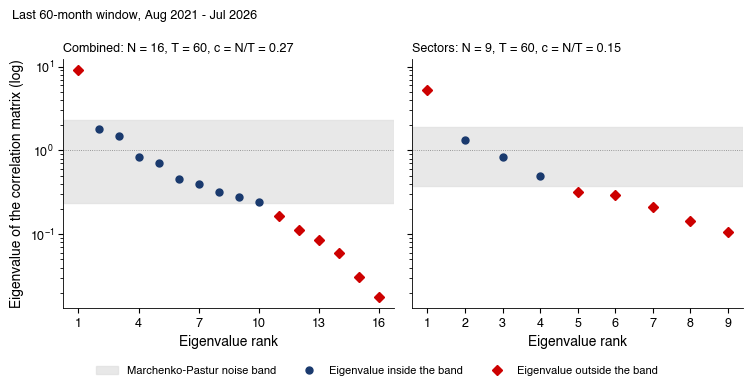

Combined (2021-08-31 – 2026-07-31): Marchenko-Pastur band [0.234, 2.299]; eigenvalues above / below the band: 1 / 6; largest eigenvalue = 56% of the trace
Sectors (2021-08-31 – 2026-07-31): Marchenko-Pastur band [0.375, 1.925]; eigenvalues above / below the band: 1 / 5; largest eigenvalue = 58% of the trace


Sectors
           Vol  Sharpe  Turnover
GMV     0.1190  0.7106    0.2336
GMV-LW  0.1180  0.6455    0.1371
GMV-NL  0.1162  0.7530    0.1809
   variance ratio GMV-NL/GMV = 0.954, GMV-NL/GMV-LW = 0.970
Combined
           Vol  Sharpe  Turnover
GMV     0.0406  0.2008    0.2360
GMV-LW  0.0438  0.2032    0.1291
GMV-NL  0.0431  0.3510    0.1997
   variance ratio GMV-NL/GMV = 1.131, GMV-NL/GMV-LW = 0.970
Lo (2002), 1/N, Sectors: Sharpe x sqrt(12) = 0.662 (s.e. 0.212); with autocorrelations 0.692 (eta = 3.62, rho1 = -0.026)
Lo (2002), 1/N, Multi-asset: Sharpe x sqrt(12) = 0.520 (s.e. 0.266); with autocorrelations 0.591 (eta = 3.94, rho1 = -0.076)
Lo (2002), 1/N, Combined: Sharpe x sqrt(12) = 0.766 (s.e. 0.268); with autocorrelations 1.086 (eta = 4.91, rho1 = -0.199)
Deflated Sharpe ratio: best of N = 24 rules = Combined: MV-LO (Sharpe 0.812 a year); expected maximum under the null 0.524; DSR = 0.842
   effective number of trials 3: threshold 0.226, DSR 0.979
   effective number of trials 8: th

In [16]:
def britten_jones(Rex):
    """Britten-Jones (1999): regression of 1 on the excess returns, without intercept.
    b ~ Sigma^-1 mu; t test of b_i = 0 (zero tangency weight) and F test of b proportional to 1 (1/N)."""
    X = np.asarray(Rex, float)
    T, N = X.shape
    y = np.ones(T)
    XtX_inv = np.linalg.inv(X.T @ X)
    b = XtX_inv @ X.T @ y
    u = y - X @ b
    s2 = u @ u / (T - N)
    se = np.sqrt(np.diag(s2 * XtX_inv))
    t = b / se
    R = np.hstack([np.eye(N - 1), np.zeros((N - 1, 1))]) - np.hstack([np.zeros((N - 1, N - 1)), np.ones((N - 1, 1))])
    Rb = R @ b
    F = Rb @ np.linalg.solve(R @ XtX_inv @ R.T, Rb) / (N - 1) / s2
    pF = 1 - stats.f.cdf(F, N - 1, T - N)
    # HAC variance (Bartlett, Newey-West), for departures from i.i.d. Normal
    L = int(np.floor(4 * (T / 100) ** (2 / 9)))
    Xu = X * u[:, None]
    Om = Xu.T @ Xu / T
    for l in range(1, L + 1):
        G = Xu[l:].T @ Xu[:-l] / T
        Om += (1 - l / (L + 1)) * (G + G.T)
    Vh = T * XtX_inv @ Om @ XtX_inv
    W = Rb @ np.linalg.solve(R @ Vh @ R.T, Rb)
    pW = 1 - stats.chi2.cdf(W, N - 1)
    w = b / b.sum()
    return dict(T=T, N=N, b=b.tolist(), w=w.tolist(), t=t.tolist(), F=float(F), pF=float(pF), df=(N - 1, T - N),
                wald_hac=float(W), p_wald_hac=float(pW), t_hac=(b / np.sqrt(np.diag(Vh))).tolist(),
                w_check=w_tan(X.mean(0), np.cov(X.T)).tolist())


def kz_bias(theta_ann, N, T):
    """Kan & Zhou (2007): E[theta_hat^2] = (T theta^2 + N)/(T - N - 2) for the maximum-likelihood Sigma_hat,
    i.i.d. Normal; returns annualised values."""
    th2 = (theta_ann / np.sqrt(12)) ** 2
    e2 = (T * th2 + N) / (T - N - 2)
    return dict(theta2_m=th2, E_theta2_m=e2, E_theta_ann_approx=float(np.sqrt(e2 * 12)),
                inv_bias=T / (T - N - 2))


def theta2_unbiased(Rex):
    """Unbiased estimator of theta^2 (Kan & Zhou 2007): ((T-N-2) theta_hat^2 - N)/T, maximum-likelihood Sigma_hat."""
    X = np.asarray(Rex, float)
    T, N = X.shape
    mu, S = X.mean(0), np.cov(X.T, bias=True)
    th2 = mu @ np.linalg.solve(S, mu)
    u = ((T - N - 2) * th2 - N) / T
    return dict(T=T, N=N, theta_hat_ann=float(np.sqrt(th2 * 12)), theta2_u=float(u),
                theta_u_ann=float(np.sqrt(max(u, 0) * 12)))


def mp_bounds(c, s2=1.0):
    """Support of the Marchenko-Pastur law for the ratio c = N/T < 1."""
    return s2 * (1 - np.sqrt(c)) ** 2, s2 * (1 + np.sqrt(c)) ** 2


def fig_mp():
    """Eigenvalues of the correlation matrix on the last 60-month window vs the Marchenko-Pastur band."""
    res = {}
    fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6), sharey=True)
    for ax, (u, syms) in zip(axes, [('Combined', COMBINED), ('Sectors', SECTORS)]):
        R, Rex, rf = us_monthly(syms)
        X = Rex.values[-WINDOW:]
        ev = np.sort(np.linalg.eigvalsh(np.corrcoef(X.T)))[::-1]
        N = len(syms)
        c = N / WINDOW
        lo, hi = mp_bounds(c)
        k = np.arange(1, N + 1)
        ax.axhspan(lo, hi, color=LightGray, alpha=0.6, label='Marchenko-Pastur noise band')
        ax.axhline(1, color=Gray, lw=0.6, ls=':')
        inside = (ev >= lo) & (ev <= hi)
        ax.plot(k[inside], ev[inside], 'o', color=MainBlue, ms=5, label='Eigenvalue inside the band')
        ax.plot(k[~inside], ev[~inside], 'D', color=IDAred, ms=5, label='Eigenvalue outside the band')
        ax.set_yscale('log')
        ax.set_xticks(k if N < 10 else k[::3])
        ax.set_xlabel('Eigenvalue rank')
        ax.set_title(f'{u}: N = {N}, T = {WINDOW}, c = N/T = {c:.2f}', fontsize=9, loc='left')
        res[u] = dict(N=N, T=WINDOW, c=c, lo=lo, hi=hi, ev=ev.tolist(), n_above=int((ev > hi).sum()),
                      n_below=int((ev < lo).sum()), share_top=float(ev[0] / N),
                      start=str(Rex.index[-WINDOW].date()), end=str(Rex.index[-1].date()))
    axes[0].set_ylabel('Eigenvalue of the correlation matrix (log)')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)
    fig.suptitle(f'Last 60-month window, {Rex.index[-WINDOW]:%b %Y} - {Rex.index[-1]:%b %Y}', fontsize=9, x=0.02, ha='left')
    plt.tight_layout()
    save_fig('ch4_mp')
    return res


def gmv_nl_backtests():
    """GMV with nonlinear shrinkage (LW 2020) vs GMV and GMV-LW, same 60-month rolling window."""
    out = {}
    for u in ['Sectors', 'Combined']:
        R, Rex, rf = us_monthly(UNIVERSES[u])
        ret, to, W = backtest(R, Rex, strategies=['GMV', 'GMV-LW', 'GMV-NL'])
        out[u] = {s: dict(vol=float(ret[s].std() * np.sqrt(12)), sharpe=float(sharpe(ret[s])),
                          turnover=float(to[s].mean())) for s in ret.columns}
        out[u]['var_ratio_nl_gmv'] = float(ret['GMV-NL'].var() / ret['GMV'].var())
        out[u]['var_ratio_nl_lw'] = float(ret['GMV-NL'].var() / ret['GMV-LW'].var())
    return out


def lo_sharpe(r, q=12):
    """Lo (2002): i.i.d. standard error of the monthly Sharpe ratio and the annualisation factor with autocorrelations."""
    r = np.asarray(r, float)
    T = len(r)
    sr = r.mean() / r.std()
    se_iid = np.sqrt((1 + sr ** 2 / 2) / T)
    rc = r - r.mean()
    rho = np.array([np.sum(rc[k:] * rc[:-k]) / np.sum(rc ** 2) for k in range(1, q)])
    eta = q / np.sqrt(q + 2 * np.sum((q - np.arange(1, q)) * rho))
    return dict(T=T, sr_m=float(sr), se_m=float(se_iid), sr_ann_sqrt=float(sr * np.sqrt(q)),
                se_ann=float(se_iid * np.sqrt(q)), eta=float(eta), sr_ann_lo=float(sr * eta),
                rho1=float(rho[0]), rho_sum=float(rho.sum()))


def deflated_sharpe(rets):
    """Bailey & Lopez de Prado (2014): deflated Sharpe ratio of the best rule out of N trials.
    rets: dict {name: series of monthly excess returns}."""
    names = list(rets)
    srs = np.array([np.mean(rets[k]) / np.std(rets[k], ddof=1) for k in names])
    N = len(srs)
    gam = 0.5772156649
    sr0 = np.sqrt(srs.var(ddof=1)) * ((1 - gam) * stats.norm.ppf(1 - 1 / N) + gam * stats.norm.ppf(1 - 1 / (N * np.e)))
    k = int(np.argmax(srs))
    r = np.asarray(rets[names[k]], float)
    T = len(r)
    g3, g4 = stats.skew(r), stats.kurtosis(r, fisher=False)
    s = srs[k]
    z = (s - sr0) * np.sqrt(T - 1) / np.sqrt(1 - g3 * s + (g4 - 1) / 4 * s ** 2)
    psr0 = stats.norm.cdf(s * np.sqrt(T - 1) / np.sqrt(1 - g3 * s + (g4 - 1) / 4 * s ** 2))
    sens = {}
    for n_eff in (3, 8, N):                  # effective number of independent trials (raw N = upper bound)
        s0 = np.sqrt(srs.var(ddof=1)) * ((1 - gam) * stats.norm.ppf(1 - 1 / n_eff) + gam * stats.norm.ppf(1 - 1 / (n_eff * np.e)))
        zz = (s - s0) * np.sqrt(T - 1) / np.sqrt(1 - g3 * s + (g4 - 1) / 4 * s ** 2)
        sens[n_eff] = dict(sr0_ann=float(s0 * np.sqrt(12)), dsr=float(stats.norm.cdf(zz)))
    return dict(N=N, best=names[k], sr_best_ann=float(s * np.sqrt(12)), sr0_ann=float(sr0 * np.sqrt(12)), n_eff=sens,
                T=T, skew=float(g3), kurt=float(g4), dsr=float(stats.norm.cdf(z)), psr0=float(psr0),
                sd_sr_ann=float(np.sqrt(srs.var(ddof=1)) * np.sqrt(12)))


R9, Rex9, rf9 = us_monthly(SECTORS)
bj = britten_jones(Rex9)
print(f"Britten-Jones, nine sectors (T = {bj['T']}): F test of 1/N = {bj['F']:.2f} (p = {bj['pF']:.3f}); "
      f"HAC Wald test = {bj['wald_hac']:.2f} (p = {bj['p_wald_hac']:.3f})")
print(pd.DataFrame({'b': bj['b'], 't': bj['t'], 't HAC': bj['t_hac'], 'b / sum(b)': bj['w'],
                    'tangency weight': bj['w_check']}, index=SECTORS).round(3))
kz = kz_bias(0.66, 9, 60)
print(f"Kan-Zhou, theta = 0.66 a year, N = 9, T = 60: E[theta_hat^2] = {kz['E_theta2_m']:.4f} a month, "
      f"i.e. a Sharpe ratio of about {kz['E_theta_ann_approx']:.2f} a year; T/(T-N-2) = {kz['inv_bias']:.3f}")
tu = theta2_unbiased(Rex9)
print(f"Full sample (T = {tu['T']}): in-sample maximum Sharpe ratio {tu['theta_hat_ann']:.3f}, "
      f"unbiased estimate {tu['theta_u_ann']:.3f} a year")
for u, d in fig_mp().items():
    print(f"{u} ({d['start']} – {d['end']}): Marchenko-Pastur band [{d['lo']:.3f}, {d['hi']:.3f}]; "
          f"eigenvalues above / below the band: {d['n_above']} / {d['n_below']}; "
          f"largest eigenvalue = {d['share_top']:.0%} of the trace")
for u, d in gmv_nl_backtests().items():
    print(u)
    print(pd.DataFrame({s: d[s] for s in ['GMV', 'GMV-LW', 'GMV-NL']}).T.rename(columns=str.capitalize).round(4))
    print(f"   variance ratio GMV-NL/GMV = {d['var_ratio_nl_gmv']:.3f}, GMV-NL/GMV-LW = {d['var_ratio_nl_lw']:.3f}")
for u in bts:
    lo = lo_sharpe(bts[u][0]['1/N'])
    print(f"Lo (2002), 1/N, {u}: Sharpe x sqrt(12) = {lo['sr_ann_sqrt']:.3f} (s.e. {lo['se_ann']:.3f}); "
          f"with autocorrelations {lo['sr_ann_lo']:.3f} (eta = {lo['eta']:.2f}, rho1 = {lo['rho1']:.3f})")
ds = deflated_sharpe({f'{u}: {s}': bts[u][0][s].values for u in bts for s in STRATS})
print(f"Deflated Sharpe ratio: best of N = {ds['N']} rules = {ds['best']} "
      f"(Sharpe {ds['sr_best_ann']:.3f} a year); expected maximum under the null {ds['sr0_ann']:.3f}; "
      f"DSR = {ds['dsr']:.3f}")
for n, v in ds['n_eff'].items():
    print(f"   effective number of trials {n}: threshold {v['sr0_ann']:.3f}, DSR {v['dsr']:.3f}")

## 8. A portfolio of BVB blue chips (RON)

- 36-month window; benchmarks BET-TR and BET; Sharpe ratios with $R_f = 0$.

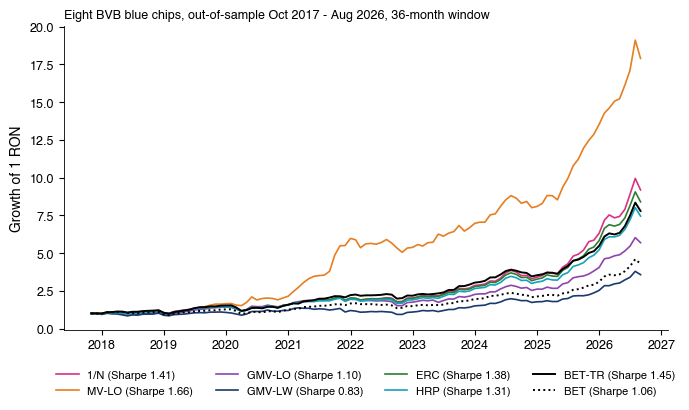

Out of sample 2017-10-31 – 2026-08-31 (T = 107); mean pairwise correlation of the eight stocks 0.44
         Mean  Volatility  Sharpe  Turnover  Max drawdown  Sharpe net 10 bp  \
1/N     0.269       0.191   1.408     0.039        -0.230             1.406   
MV-LO   0.349       0.210   1.661     0.163        -0.202             1.651   
GMV-LO  0.215       0.196   1.098     0.196        -0.283             1.086   
GMV-LW  0.163       0.197   0.826     0.174        -0.321             0.815   
ERC     0.258       0.188   1.375     0.050        -0.219             1.372   
HRP     0.244       0.186   1.313     0.094        -0.216             1.307   
BET-TR  0.247       0.170   1.449     0.000        -0.240             1.449   
BET     0.178       0.168   1.065     0.000        -0.240             1.065   

        Sharpe net 50 bp  
1/N                1.396  
MV-LO              1.612  
GMV-LO             1.038  
GMV-LW             0.773  
ERC                1.360  
HRP                1.284  

In [17]:
BVB_BLOCKS = {'1/N': 4, 'MV-LO': 1, 'GMV-LO': 6, 'GMV-LW': 4, 'ERC': 4, 'HRP': 4}
def bvb_backtest(window=36):
    m, removed = bvb_monthly()
    R = m[BVB]
    ret, to, W = backtest(R, R, window=window, strategies=BVB_STRATS)
    bench = m.loc[ret.index, ['BET-TR', 'BET']]
    return ret, to, W, bench, removed, m


def fig_bvb(bb, n_jobs=1, blocks=None):
    ret, to, W, bench, removed, m = bb
    fig, ax = plt.subplots(figsize=(7.2, 4.2))
    for s in BVB_STRATS:
        ax.plot(ret.index, np.cumprod(1 + ret[s]), color=SCOL[s], lw=1.2, label=f'{s} (Sharpe {sharpe(ret[s]):.2f})')
    for b, c, ls in [('BET-TR', 'black', '-'), ('BET', 'black', ':')]:
        ax.plot(bench.index, np.cumprod(1 + bench[b]), color=c, ls=ls, lw=1.4, label=f'{b} (Sharpe {sharpe(bench[b]):.2f})')
    ax.set_ylabel('Growth of 1 RON')
    ax.set_title(f'Eight BVB blue chips, out-of-sample {ret.index[0]:%b %Y} - {ret.index[-1]:%b %Y}, '
                 '36-month window', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=4, y=-0.1)
    plt.tight_layout()
    save_fig('ch4_bvb')
    tab = summary(ret, to)
    for b in ['BET-TR', 'BET']:
        tab.loc[b] = dict(mean=bench[b].mean() * 12, vol=bench[b].std() * np.sqrt(12), sharpe=sharpe(bench[b]),
                          turnover=0, mdd=max_drawdown(bench[b]), sharpe_10bp=sharpe(bench[b]),
                          sharpe_50bp=sharpe(bench[b]))
    res = run_tests({s: (ret[s], bench['BET-TR']) for s in BVB_STRATS}, n_jobs, blocks)
    tests = {s: res[s][0] for s in BVB_STRATS}
    return dict(table=tab.round(4).to_dict(orient='index'), tests=tests, removed=removed,
                start=str(ret.index[0].date()), end=str(ret.index[-1].date()), T=len(ret),
                corr_mean=float(m[BVB].corr().values[np.triu_indices(len(BVB), 1)].mean()),
                w_last={s: W[s].iloc[-1].round(3).to_dict() for s in BVB_STRATS})


bvb = fig_bvb(bvb_backtest(), blocks=BVB_BLOCKS)
print(f"Out of sample {bvb['start']} – {bvb['end']} (T = {bvb['T']}); mean pairwise correlation of the eight stocks {bvb['corr_mean']:.2f}")
print(pd.DataFrame(bvb['table']).T.rename(columns=SUMCOLS).round(3))
print('Each rule minus BET-TR')
print(pd.DataFrame(bvb['tests']).T[['diff', 'p_hac', 'p_boot', 'block']].astype(float).rename(columns={'diff': 'Sharpe difference', 'p_hac': 'p HAC', 'p_boot': 'p bootstrap', 'block': 'Block length'}).round(3))

## Conclusions

- Estimation error dominates: the sample tangency portfolio needs about 40 years of data to beat 1/N on nine sectors.
- Out of sample, sample MV fails in every universe; constraints, shrinkage and risk-based rules are stable.
- No rule beats 1/N significantly; GMV rules lose on the combined universe; costs widen the gaps.
- BVB: compare with BET-TR, not BET; no optimised BVB-only rule beats BET-TR significantly.